# From hdWGCNA (R) to LIANA+ (Python): cell-cell communication in the aging mouse heart



## 1. Installation and imports


In [1]:
import numpy as np

# Compatibility patch for older libraries (e.g. cell2cell) that still reference the
# `np.unicode_` alias removed in NumPy 2.0
if not hasattr(np, 'unicode_'):
    np.unicode_ = str

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import plotnine as p9

import liana as li
import cell2cell as c2c
import decoupler as dc

%matplotlib inline
sns.set_style('whitegrid')


In [3]:
# GPU is optional for tensor-cell2cell (set use_gpu = False if you don't have one)
use_gpu = False

if use_gpu:
    import torch, tensorly as tl
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cuda":
        tl.set_backend('pytorch')
else:
    device = "cpu"

device


'cpu'

In [7]:
def _is_recoverable_log2fc_error(e):
    """log2FC is the fragile method in the default consensus: it has no `magnitude` score
    (can trigger `KeyError: \"[None] not found in axis\"` on some liana-py/pandas versions),
    and it divides by the number of 'rest' cells when comparing a group to everything else
    (raises `ZeroDivisionError` when a sample/mouse has only one cell type represented, so
    'rest' is empty). Both are library-level issues with log2FC, not a mistake in your call."""
    if isinstance(e, ZeroDivisionError):
        return True
    if isinstance(e, KeyError) and 'None' in str(e):
        return True
    return False


def _rank_aggregate_without_log2fc():
    safe_methods = [m for m in li.mt.rank_aggregate.methods if m.method_name.lower() != 'log2fc']
    return li.mt.AggregateClass(li.mt.aggregate_meta, methods=safe_methods)


def run_rank_aggregate_safe(adata, **kwargs):
    """Run li.mt.rank_aggregate, retrying without the log2FC method if it hits one of the
    known issues above. Permanent fix to try first: `pip install -U liana`."""
    try:
        li.mt.rank_aggregate(adata, **kwargs)
    except (KeyError, ZeroDivisionError) as e:
        if not _is_recoverable_log2fc_error(e):
            raise
        print(f"Known liana-py issue in the 'log2FC' method ({type(e).__name__}) -- retrying "
              "the consensus without it. Run `pip install -U liana` to check for a permanent fix.")
        _rank_aggregate_without_log2fc()(adata, **kwargs)


def run_rank_aggregate_by_sample_safe(adata, **kwargs):
    """Same workaround as `run_rank_aggregate_safe`, for the `.by_sample` variant used in
    Section 7. `ZeroDivisionError` here is especially likely if some mice have cells of only one
    cell type -- see the coverage filtering in Section 7.0."""
    try:
        li.mt.rank_aggregate.by_sample(adata, **kwargs)
    except (KeyError, ZeroDivisionError) as e:
        if not _is_recoverable_log2fc_error(e):
            raise
        print(f"Known liana-py issue in the 'log2FC' method ({type(e).__name__}) -- retrying "
              "the consensus without it. Run `pip install -U liana` to check for a permanent fix.")
        _rank_aggregate_without_log2fc().by_sample(adata, **kwargs)


## 2. Load your data: exported AnnData + hdWGCNA tables

In [9]:
DATA_DIR = Path(".")  # adjust if your files live elsewhere

adata = sc.read_h5ad(DATA_DIR / "heart_for_liana.h5ad")

hub_genes     = pd.read_csv(DATA_DIR / "hub_genes_by_module.csv")     # gene_celltype, module, celltype, gene, kME
module_age    = pd.read_csv(DATA_DIR / "module_age_correlation.csv")  # module, correlation, p_value, n_mice, fdr
all_genes_mod = pd.read_csv(DATA_DIR / "all_genes_by_module.csv")     # gene_celltype, module, celltype, gene(, kME)

# Drop cells with a missing/invalid cell type label. Left-over NaN/"None" categories are a common
# cause of empty features and of grouping/plotting errors further down the notebook.
adata = adata[adata.obs['final_celltype'].notna()].copy()
adata.obs['final_celltype'] = adata.obs['final_celltype'].astype(str)
adata = adata[~adata.obs['final_celltype'].isin(['None', 'nan', 'NaN'])].copy()
adata.obs['final_celltype'] = adata.obs['final_celltype'].astype('category')

adata


AnnData object with n_obs × n_vars = 10330 × 20633
    obs: 'final_celltype', 'sample_id', 'age', 'tech'
    layers: 'counts', None (.X)

In [10]:
# Sanity checks, same variable names as in your Rmd
print(adata.obs['final_celltype'].value_counts())
print()
print("Mice (sample_id):", adata.obs['sample_id'].nunique())
print("Ages present:", sorted(adata.obs['age'].unique(),
                               key=lambda a: float(''.join(c for c in a if c.isdigit() or c == '.'))))


final_celltype
Fibroblasts          4041
EndothelialCells     3423
Leukocytes           1286
EndocardialCells      708
Myocytes              454
SmoothMuscleCells     418
Name: count, dtype: int64

Mice (sample_id): 24
Ages present: ['1m', '3m', '18m', '21m', '24m', '30m']


In [13]:
# Chronological age order (same idea as `ordered_age_levels` in your Rmd)
age_order = sorted(adata.obs['age'].unique(),
                    key=lambda a: float(''.join(c for c in a if c.isdigit() or c == '.')))
adata.obs['age'] = pd.Categorical(adata.obs['age'], categories=age_order, ordered=True)

groupby       = 'final_celltype'
sample_key    = 'sample_id'
condition_key = 'age'

assert 'counts' in adata.layers


### 2.1 Verify normalization (fixes the "assuming ... log-normalized" / raw-data warning)

`li.mt.rank_aggregate` always prints a line like `Assuming that counts were natural log-normalized!`
or `Make sure that normalized counts are passed!` -- **this is a fixed disclaimer LIANA+ prints on
every run, not a detection that your data is actually raw.** LIANA+ has no way to check this itself;
it trusts whatever is in `.X` (or the `layer=` you point it to) and just reminds you to make sure
it's log-normalized.

That said, it's worth checking directly rather than trusting the R export blindly. The cell below
inspects `adata.X`: log-normalized data should be non-integer and roughly in the 0-10 range; raw
counts are non-negative integers with a much wider range. If it turns out `.X` is actually raw, we
recompute the log-normalization here in Python from `adata.layers['counts']`, so the rest of the
notebook is correct regardless of what happened on the R side.


In [15]:


def _peek_dense(x, n=500):
    x = x[:n]
    return x.toarray() if hasattr(x, 'toarray') else np.asarray(x)

sample = _peek_dense(adata.X)
looks_integer = np.allclose(sample, np.round(sample))
print(f"adata.X value range: [{sample.min():.3f}, {sample.max():.3f}]")
print(f"adata.X looks like raw (integer) counts: {looks_integer}")

if looks_integer:
    print("\n'.X' looks like raw counts, not log-normalized data -- normalizing now from "
          "adata.layers['counts'] so the rest of the notebook uses the right values.")
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
else:
    print("\n'.X' already looks log-normalized -- keeping it as is.")

# Keep an explicit, stable copy: every LIANA+ call below points at this layer by name
# (via `layer='lognorm'`), so it never silently depends on whatever `.X` happens to hold.
adata.layers['lognorm'] = adata.X.copy()


adata.X value range: [0.000, 3.217]
adata.X looks like raw (integer) counts: False

'.X' already looks log-normalized -- keeping it as is.


## 3. Exploratory visualization

Quick look at the dataset before running any LR inference: cell-type composition, age distribution,
and (if you exported it) the UMAP embedding colored by cell type, age, and sequencing technology.


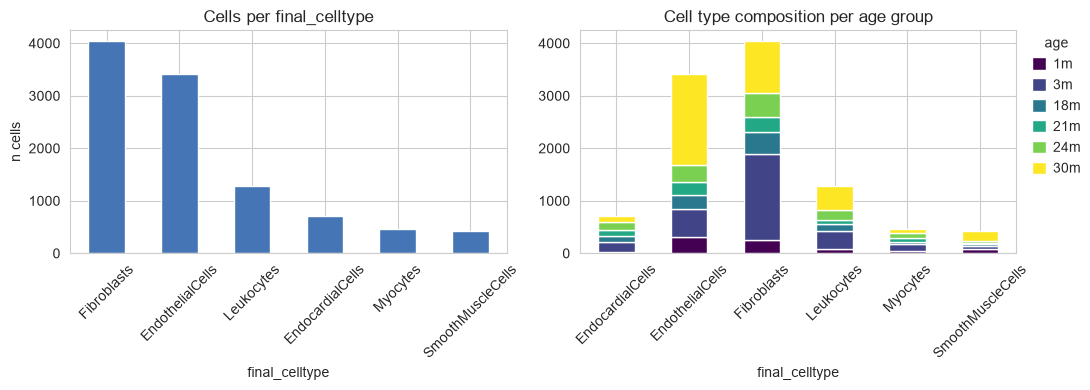

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

adata.obs['final_celltype'].value_counts().plot.bar(ax=axes[0], color='#4575b4')
axes[0].set_title('Cells per final_celltype')
axes[0].set_ylabel('n cells')
axes[0].tick_params(axis='x', rotation=45)

pd.crosstab(adata.obs['final_celltype'], adata.obs['age']).plot.bar(
    stacked=True, ax=axes[1], colormap='viridis'
)
axes[1].set_title('Cell type composition per age group')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='age', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('cell_type_composition.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


In [9]:
# UMAP colored by cell type, age, and technology (only if X_umap was exported from R)
if 'X_umap' in adata.obsm:
    sc.pl.umap(adata, color=['final_celltype', 'age', 'tech'], ncols=3, frameon=False, wspace=0.3)
else:
    print("No 'X_umap' in adata.obsm -- add the UMAP export step in the R chunk above to enable this plot.")


No 'X_umap' in adata.obsm -- add the UMAP export step in the R chunk above to enable this plot.


## 4. Steady-state LR inference (adapted from `basic_usage.html`)

Key difference from the original tutorial (which uses human PBMCs): here we use
`resource_name='mouseconsensus'` because your genes are mouse gene symbols.


In [10]:
li.mt.show_methods()


,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [10]:
# Check resource coverage against your genes before running anything
mouse_resource = li.resource.select_resource('mouseconsensus')
resource_genes = set(mouse_resource['ligand']) | set(mouse_resource['receptor'])
overlap = resource_genes & set(adata.var_names)
print(f"Mouse LR panel genes present in your data: {len(overlap)} / {len(resource_genes)}")


Mouse LR panel genes present in your data: 1501 / 1741


In [11]:
# Run LIANA on the full dataset (all 4 cell types together), method consensus,
# same as `li.mt.rank_aggregate` in the tutorial. Uses the safe wrapper from Section 1.
run_rank_aggregate_safe(
    adata,
    groupby=groupby,
    resource_name='mouseconsensus',   # <- key: mouse, not 'consensus' (human)
    expr_prop=0.1,
    use_raw=False,                    # ignore adata.raw entirely
    layer='lognorm',                  # explicit: always the log-normalized layer verified in 2.1
    verbose=True,
)

adata.uns['liana_res'].sort_values('magnitude_rank').head(10)


Using resource `mouseconsensus`.
Using the `lognorm` layer!
Converting to sparse csr matrix!
3 features of mat are empty, they will be removed.
0.05 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 10330 samples and 1531 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:07<00:00, 126.93it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
9054,Myocytes,EndocardialCells,Nppa,Npr3,2.226219,0.0,4.951212,2.138384,2.470178,0.291495,0.922377,0.000019,4.905997e-08
10507,Myocytes,Myocytes,S100a1,Ryr2,1.799485,0.0,3.219461,2.458689,2.115797,0.277047,0.905500,0.000016,1.962302e-07
2745,EndothelialCells,EndothelialCells,Gnai2,Cav1,1.774677,0.0,3.135817,0.802798,1.108650,0.070932,0.904367,0.028542,4.414962e-07
13378,SmoothMuscleCells,SmoothMuscleCells,Mfge8,Pdgfrb,1.765756,0.0,3.116308,1.450235,1.412231,0.176488,0.904097,0.003955,7.848436e-07
7434,Leukocytes,EndothelialCells,Gnai2,Cav1,1.760272,0.0,3.081324,0.773371,1.024731,0.069700,0.903607,0.028542,1.226258e-06
2605,EndothelialCells,EndocardialCells,Sparc,Eng,1.715951,0.0,2.900707,0.754316,0.643402,0.077916,0.900944,0.028542,1.765724e-06
1100,EndocardialCells,Fibroblasts,Vwf,Lrp1,1.708264,0.0,2.858587,1.744844,2.050287,0.342105,0.900289,0.000056,3.138756e-06
605,EndocardialCells,EndothelialCells,Mmrn2,Cd93,1.700868,0.0,2.875457,1.175745,1.505138,0.170118,0.900553,0.004898,3.138756e-06
2324,EndocardialCells,SmoothMuscleCells,Vwf,Itgb1,1.699269,0.0,2.823462,1.493814,1.404220,0.153954,0.899733,0.006364,3.972292e-06
4529,Fibroblasts,EndocardialCells,Sparc,Eng,1.690989,0.0,2.804593,0.706842,0.608045,0.075334,0.899430,0.028542,4.903823e-06


### 4.1 Visualization gallery for the full-dataset run

Dotplot, tileplot, circle/network plot, and a source x target heatmap of interaction counts --
four complementary views of the same result.


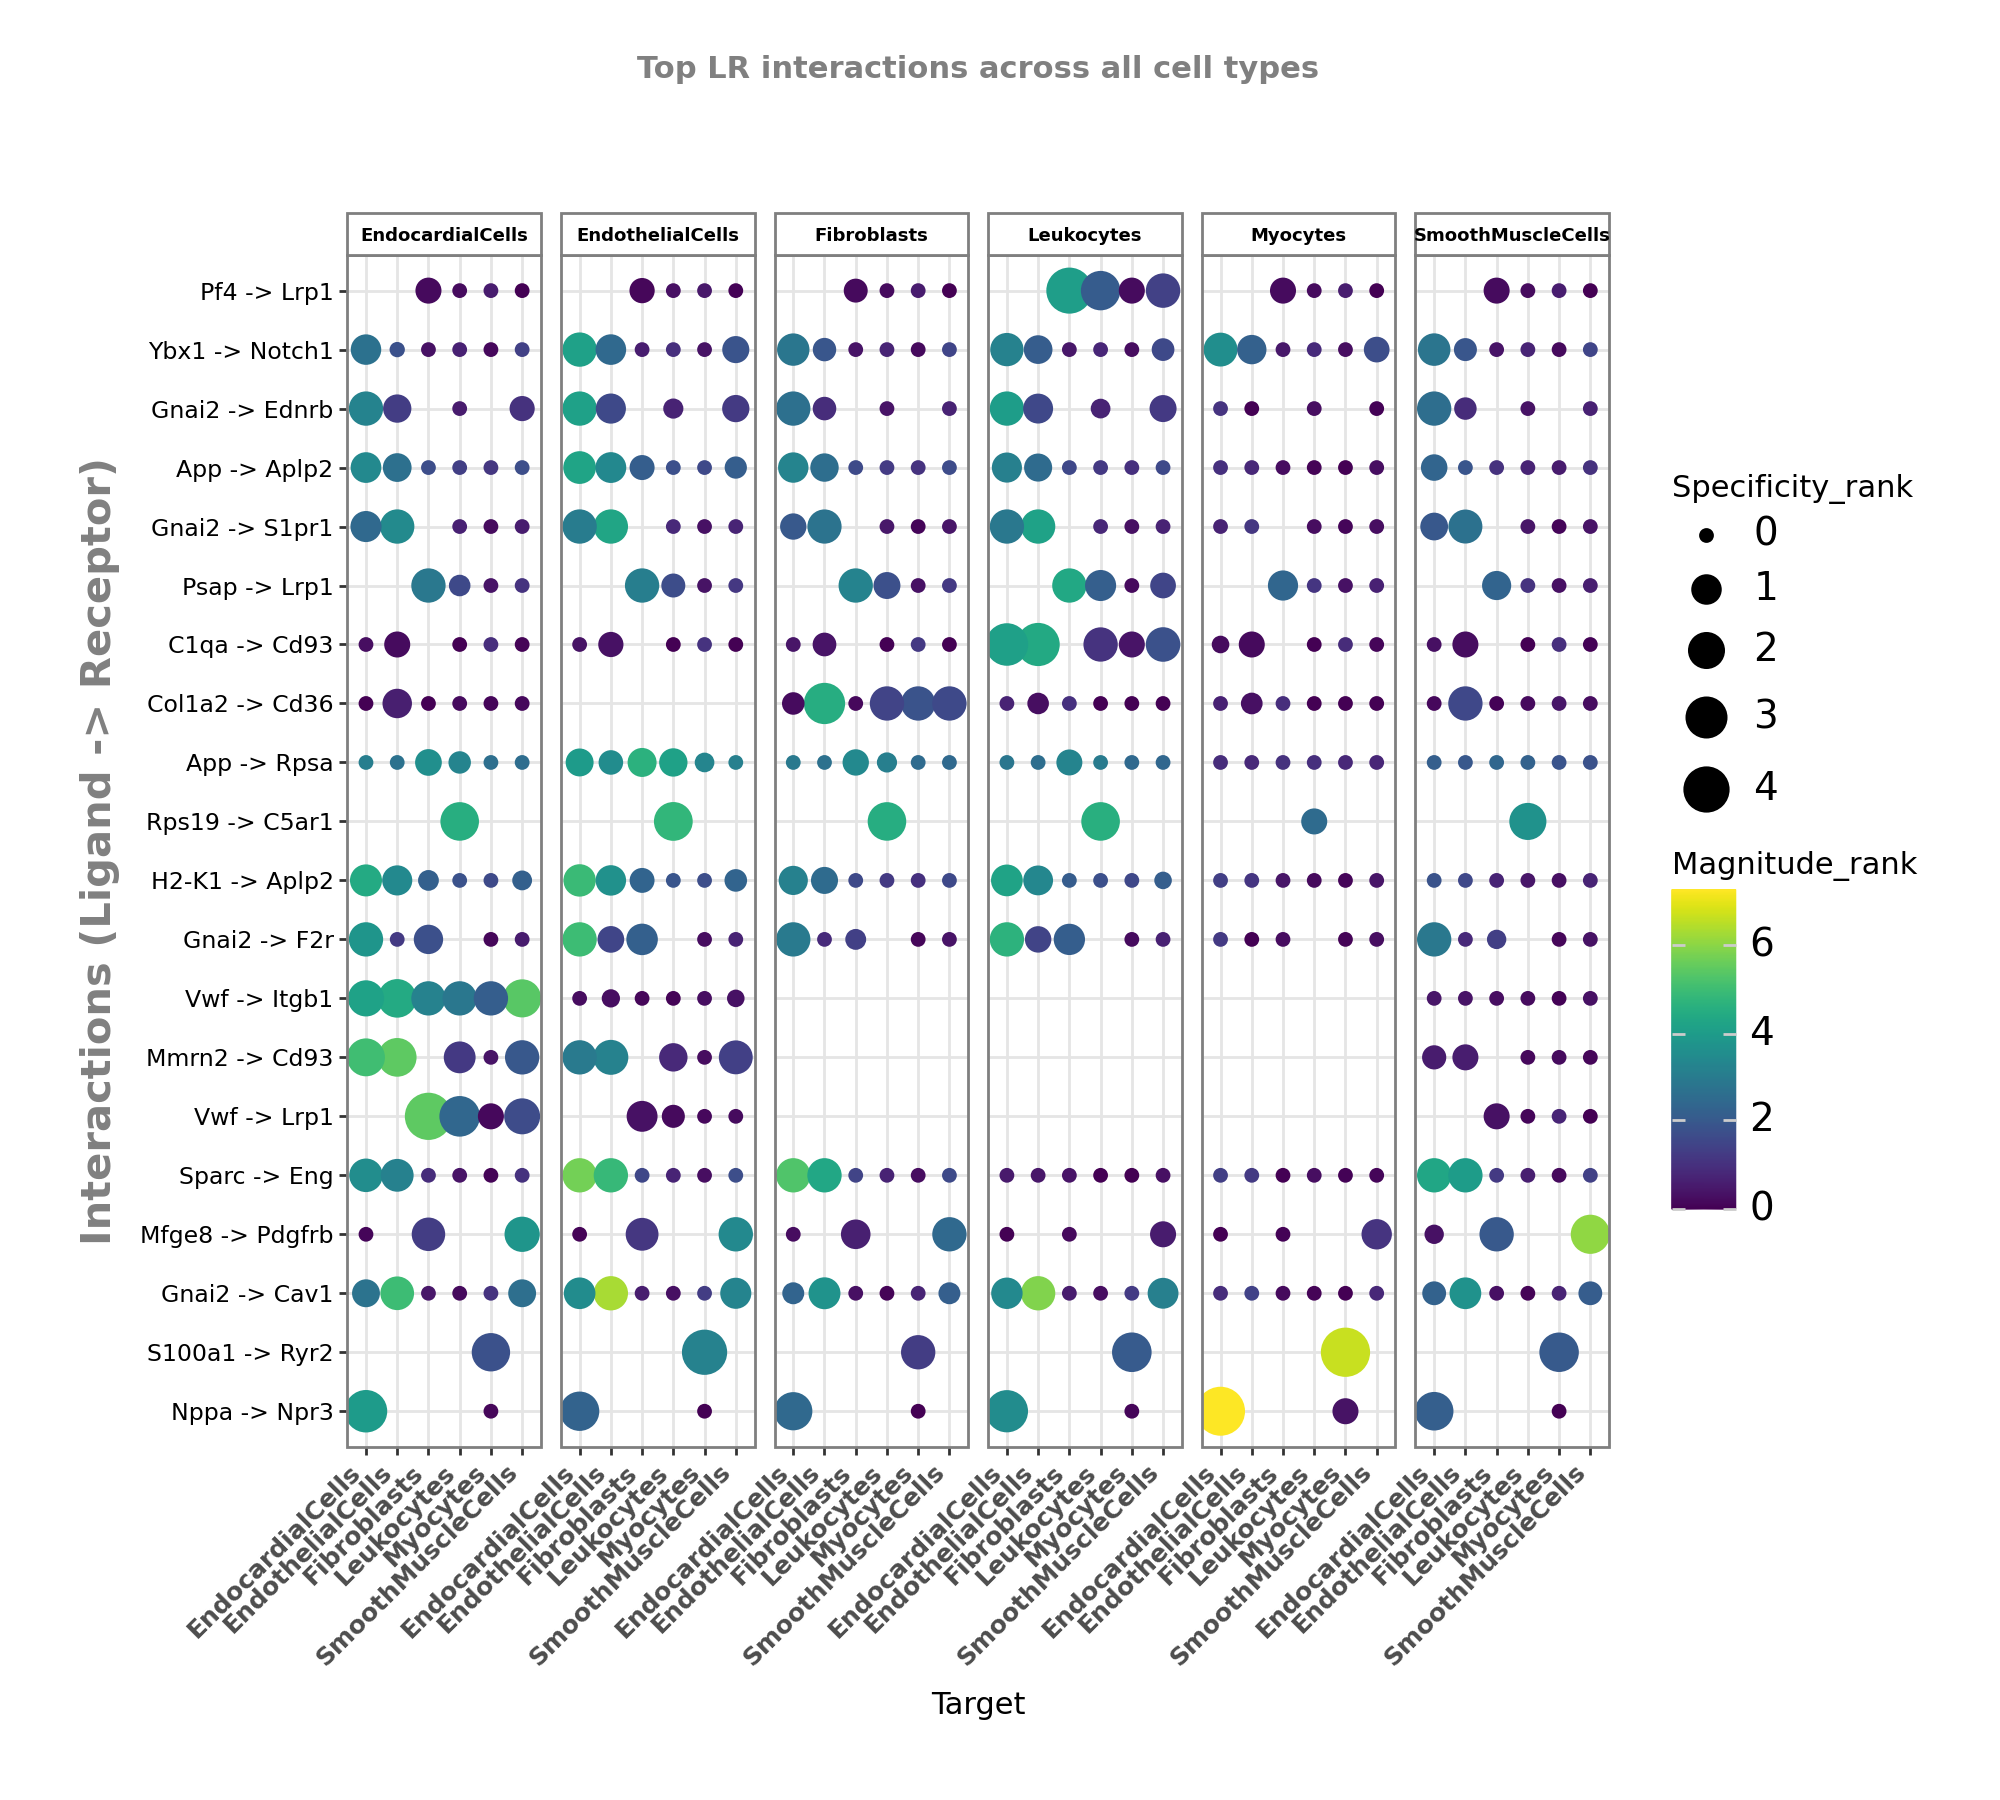

In [38]:
import plotnine as p9

p_dot = (
    li.pl.dotplot(
        adata=adata,
        colour='magnitude_rank',
        inverse_colour=True,
        size='specificity_rank',
        inverse_size=True,
        top_n=20,
        orderby='magnitude_rank',
        orderby_ascending=True,
        uns_key='liana_res',
        figure_size=(10, 9),
    )
    # El '\n' al final agrega un margen invisible debajo del título
    + p9.ggtitle('Top LR interactions across all cell types\n')
     + p9.theme(
        plot_title=p9.element_text(size=11, face='bold', margin={'b': 15, 't': 10}),
        axis_text_x=p9.element_text(rotation=45, hjust=1, vjust=1, size=9),
        axis_text_y=p9.element_text(size=8.5),
        strip_text=p9.element_text(size=6.5, face='bold'),
        plot_margin=0.04
    )
)

# Exportar a PDF
p_dot.save('liana_dotplot.pdf', width=11, height=8.5, dpi=300)
p_dot

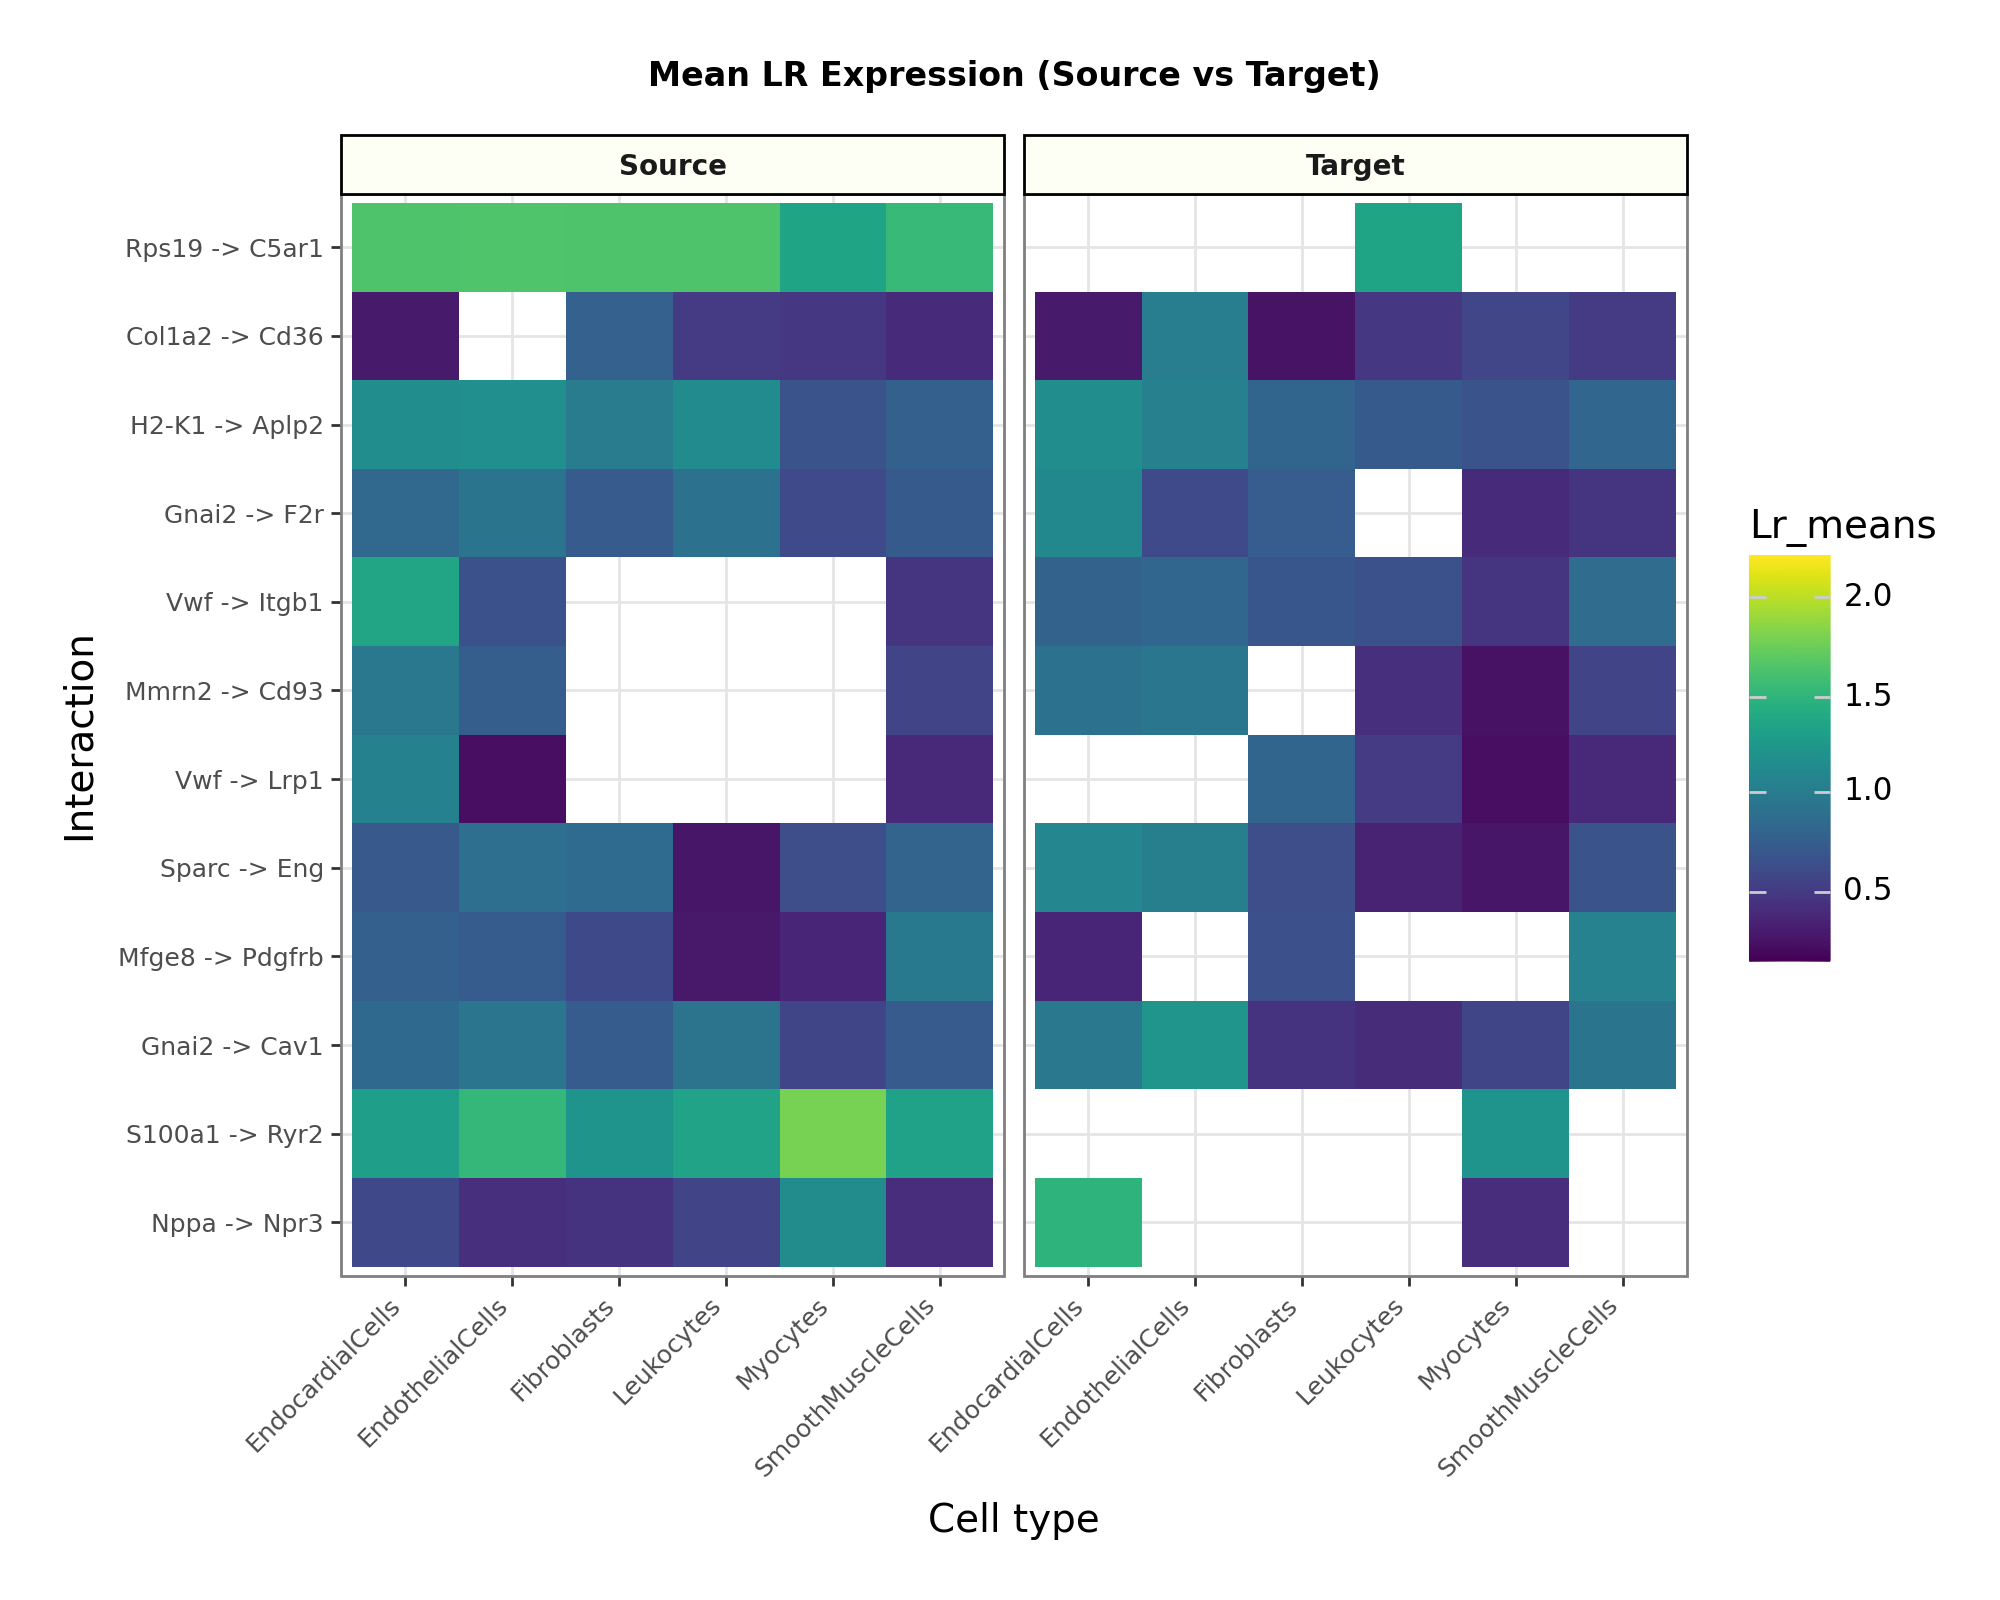

In [13]:

adata.uns['liana_res']['clean_label'] = ' '

p_tile = (
    li.pl.tileplot(
        adata=adata,
        fill='lr_means',
        label='clean_label',  
        top_n=12,
        orderby='lr_means',        
        orderby_ascending=False,   
        uns_key='liana_res',
        figure_size=(10, 8),
        return_fig=True
    )
    + p9.ggtitle('Mean LR Expression (Source vs Target)')
    + p9.theme(
        axis_text_x=p9.element_text(rotation=45, hjust=1, vjust=1, size=9),
        axis_text_y=p9.element_text(size=9),
        strip_text=p9.element_text(size=10, face='bold'),
        plot_title=p9.element_text(size=12, face='bold', margin={'b': 12}),
        plot_margin=0.03
    )
)

p_tile.save("liana_tileplot_clean.pdf", width=10, height=8, dpi=300)
p_tile

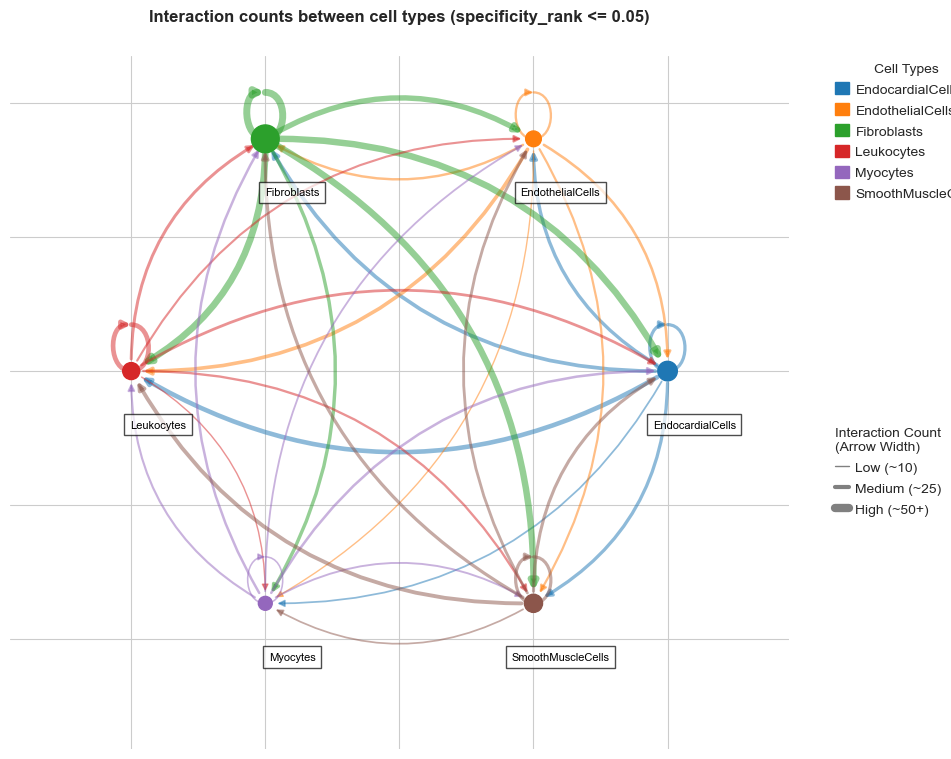

In [14]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

li.pl.circle_plot(
    adata,
    groupby=groupby,
    score_key='magnitude_rank',
    inverse_score=True,
    filter_fun=lambda x: x['specificity_rank'] <= 0.05,
    pivot_mode='counts',
    figure_size=(12, 9),
)


cell_types = adata.obs[groupby].cat.categories

if f'{groupby}_colors' in adata.uns:
    colors = adata.uns[f'{groupby}_colors']
else:
    colors = plt.cm.tab10.colors[: len(cell_types)]

cell_handles = [
    mpatches.Patch(color=colors[i], label=ct) for i, ct in enumerate(cell_types)
]

leg1 = plt.legend(
    handles=cell_handles,
    title='Cell Types',
    bbox_to_anchor=(1.05, 1.0),
    loc='upper left',
    frameon=False,
)
plt.gca().add_artist(leg1)  # Mantiene activa leg1 al añadir leg2


width_handles = [
    mlines.Line2D([], [], color='gray', linewidth=1, label='Low (~10)'),
    mlines.Line2D([], [], color='gray', linewidth=3, label='Medium (~25)'),
    mlines.Line2D([], [], color='gray', linewidth=6, label='High (~50+)'),
]

leg2 = plt.legend(
    handles=width_handles,
    title='Interaction Count\n(Arrow Width)',
    bbox_to_anchor=(1.05, 0.40),
    loc='center left',
    frameon=False,
)


plt.title(
    'Interaction counts between cell types (specificity_rank <= 0.05)',
    fontsize=12,
    fontweight='bold',
    pad=25
)


plt.savefig(
    'liana_circle_plot_counts.pdf',
    format='pdf',
    bbox_inches='tight',
    dpi=300
)

plt.show()

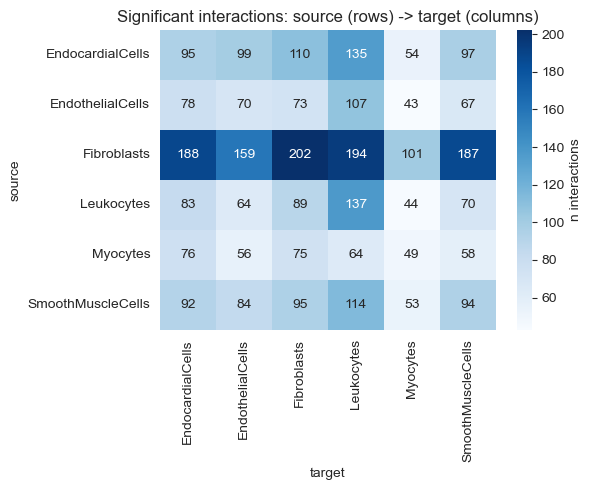

In [15]:

sig = adata.uns['liana_res'][adata.uns['liana_res']['specificity_rank'] <= 0.05]
count_mat = sig.pivot_table(index='source', columns='target', values='ligand_complex',
                             aggfunc='count', fill_value=0)

plt.figure(figsize=(6, 5))
sns.heatmap(count_mat, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'n interactions'})
plt.title('Significant interactions: source (rows) -> target (columns)')
plt.tight_layout()
plt.savefig('heatmap.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


## 5. Young vs. old comparison

Same call as above, run separately on the youngest and oldest age groups, so results are directly
comparable cell-type by cell-type.


In [19]:
young_label = age_order[1]
old_label   = age_order[-1]

adata_young = adata[adata.obs['age'] == young_label].copy()
adata_old   = adata[adata.obs['age'] == old_label].copy()

for label, ad_sub in [('young', adata_young), ('old', adata_old)]:
    run_rank_aggregate_safe(
        ad_sub, groupby=groupby, resource_name='mouseconsensus',
        expr_prop=0.1, use_raw=False, layer='lognorm', verbose=False,
    )
    print(label, ad_sub.uns['liana_res'].shape)


young (15228, 13)
old (10355, 13)


In [18]:
import io
from PIL import Image

cell_type_col = "final_celltype"
senders = adata_young.obs[cell_type_col].unique()

for sender in senders:
    safe_sender_name = str(sender).replace(" ", "_").replace("/", "_")
    pdf_filename = f"dotplot_sender_{safe_sender_name}.pdf"

    # 1. Define plotnine dotplots
    p_young = (
        li.pl.dotplot(
            adata=adata_young,
            colour="magnitude_rank",
            inverse_colour=True,
            size="spec_weight",
            inverse_size=False,
            source_labels=[sender],
            top_n=15,
            orderby="magnitude_rank",
            orderby_ascending=True,
            uns_key="liana_res",
            figure_size=(6.5, 6),
        )
        + p9.ggtitle(f"{sender} as senders -- {young_label}")
    )

    p_old = (
        li.pl.dotplot(
            adata=adata_old,
            colour="magnitude_rank",
            inverse_colour=True,
            size="spec_weight",
            inverse_size=False,
            source_labels=[sender],
            top_n=15,
            orderby="magnitude_rank",
            orderby_ascending=True,
            uns_key="liana_res",
            figure_size=(6.5, 6),
        )
        + p9.ggtitle(f"{sender} as senders -- {old_label}")
    )

    # 2. Render plotnine plots to standard Matplotlib figures
    fig_young = p_young.draw()
    fig_old = p_old.draw()

    # 3. Save each figure to an in-memory buffer
    buf_young = io.BytesIO()
    buf_old = io.BytesIO()

    fig_young.savefig(buf_young, format="png", dpi=300, bbox_inches="tight")
    fig_old.savefig(buf_old, format="png", dpi=300, bbox_inches="tight")

    plt.close(fig_young)
    plt.close(fig_old)

    # 4. Open images with PIL and combine into a side-by-side figure
    buf_young.seek(0)
    buf_old.seek(0)
    img_young = Image.open(buf_young)
    img_old = Image.open(buf_old)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    axes[0].imshow(img_young)
    axes[0].axis("off")

    axes[1].imshow(img_old)
    axes[1].axis("off")

    plt.subplots_adjust(wspace=0.02)

    # 5. Save the combined layout as PDF
    plt.savefig(pdf_filename, format="pdf", bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"PDF generado exitosamente: {pdf_filename}")

PDF generado exitosamente: dotplot_sender_EndothelialCells.pdf
PDF generado exitosamente: dotplot_sender_Fibroblasts.pdf
PDF generado exitosamente: dotplot_sender_Myocytes.pdf
PDF generado exitosamente: dotplot_sender_EndocardialCells.pdf
PDF generado exitosamente: dotplot_sender_SmoothMuscleCells.pdf
PDF generado exitosamente: dotplot_sender_Leukocytes.pdf


In [21]:
import logging

# Silenciar los mensajes de depuración de fontTools al guardar PDFs
logging.getLogger("fontTools").setLevel(logging.WARNING)
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)

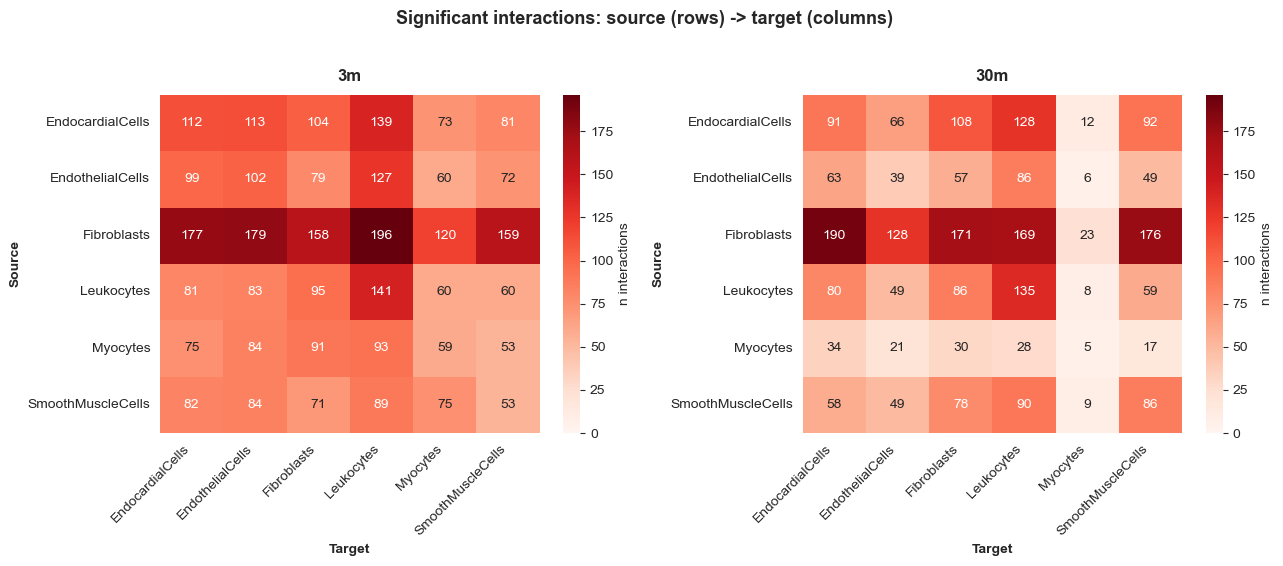

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
max_val = 0
for ad in [adata_young, adata_old]:
    res = ad.uns['liana_res']
    if isinstance(res, dict):
        res = pd.concat(res.values(), ignore_index=True)
    if 'specificity_rank' in res.columns:
        res = res[res['specificity_rank'] <= 0.05]
    count_max = res.pivot_table(index='source', columns='target', values='ligand_complex', aggfunc='count', fill_value=0).values.max()
    if count_max > max_val:
        max_val = count_max


for ax, label, ad_sub in [(axes[0], young_label, adata_young), (axes[1], old_label, adata_old)]:
    sig_sub = ad_sub.uns['liana_res']
    if isinstance(sig_sub, dict):
        sig_sub = pd.concat(sig_sub.values(), ignore_index=True)
        
    if 'specificity_rank' in sig_sub.columns:
        sig_sub = sig_sub[sig_sub['specificity_rank'] <= 0.05]
        
    mat = sig_sub.pivot_table(index='source', columns='target', values='ligand_complex',
                              aggfunc='count', fill_value=0)
    
    # Heatmap con escala compartida
    sns.heatmap(
        mat, annot=True, fmt='d', cmap='Reds', ax=ax,
        vmin=0, vmax=max_val,
        cbar_kws={'label': 'n interactions'}
    )
    
    ax.set_title(f'{label}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Target', fontsize=10, fontweight='bold')
    ax.set_ylabel('Source', fontsize=10, fontweight='bold')
    

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


plt.suptitle('Significant interactions: source (rows) -> target (columns)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

# Exportar a PDF vectorial de alta calidad
plt.savefig('heatmap_young_vs_old.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

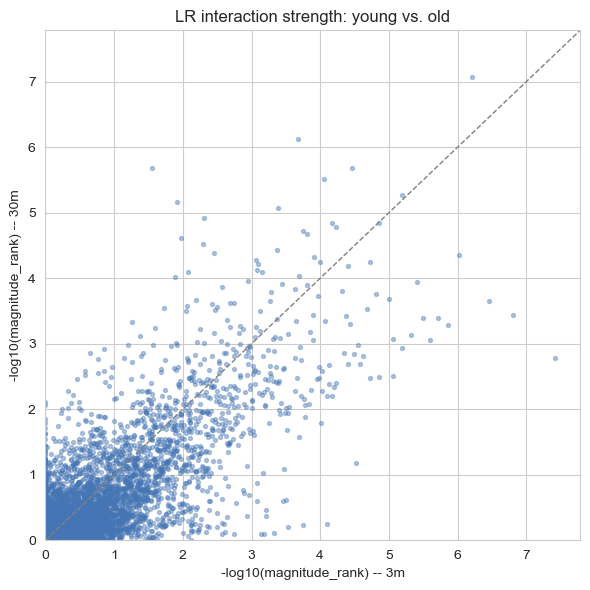

In [21]:
# Scatter comparison: magnitude_rank in young vs. old for LR pairs shared between both runs
def pair_id(df):
    return df['ligand_complex'] + '^' + df['receptor_complex'] + '__' + df['source'] + '->' + df['target']

y = adata_young.uns['liana_res'].assign(pair_id=lambda d: pair_id(d)).set_index('pair_id')['magnitude_rank']
o = adata_old.uns['liana_res'].assign(pair_id=lambda d: pair_id(d)).set_index('pair_id')['magnitude_rank']

shared = pd.concat([y.rename('young'), o.rename('old')], axis=1).dropna()
shared['neg_log_young'] = -np.log10(shared['young'] + 1e-12)
shared['neg_log_old']   = -np.log10(shared['old'] + 1e-12)

plt.figure(figsize=(6, 6))
plt.scatter(shared['neg_log_young'], shared['neg_log_old'], s=8, alpha=0.4, color='#4575b4')
lims = [0, max(shared['neg_log_young'].max(), shared['neg_log_old'].max()) * 1.05]
plt.plot(lims, lims, ls='--', color='grey', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel(f'-log10(magnitude_rank) -- {young_label}')
plt.ylabel(f'-log10(magnitude_rank) -- {old_label}')
plt.title('LR interaction strength: young vs. old')
plt.tight_layout()
plt.savefig('scatter_young_vs_old.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


## 6. Annotate LIANA results with your hdWGCNA modules

Every LIANA interaction has a `ligand_complex`/`receptor_complex` and a `source`/`target` (cell type).
In your WGCNA pseudobulk, each feature is `gene_celltype` (e.g. `Postn_Fibroblasts`), so we join on
(gene, sender cell type) for the ligand side and (gene, receiver cell type) for the receptor side.


In [23]:
module_age

,module,correlation,p_value,n_mice,fdr
0,midnightblue,-0.536710,0.006851,24,0.119897
1,lightcyan,0.551284,0.005234,24,0.119897
2,orange,0.504132,0.012008,24,0.140091
3,yellow,-0.446855,0.028587,24,0.166756
4,tan,0.452215,0.026512,24,0.166756
5,brown,0.472271,0.019794,24,0.166756
6,pink,-0.400233,0.052629,24,0.194843
7,greenyellow,-0.400356,0.052550,24,0.194843
8,black,-0.395627,0.055669,24,0.194843
9,darkorange,0.405201,0.049496,24,0.194843


In [24]:
def annotate_side(df, gene_col, celltype_col, ref_table, suffix):
    """Annotate the hdWGCNA module/kME for one side (ligand or receptor) of each LIANA interaction.
    ref_table: hub_genes or all_genes_mod, with columns gene, celltype, module (and kME if present)."""
    ref = ref_table[['gene', 'celltype', 'module'] + (['kME'] if 'kME' in ref_table.columns else [])].copy()
    ref = ref.rename(columns={
        'gene': gene_col, 'celltype': celltype_col,
        'module': f'module_{suffix}', **({'kME': f'kME_{suffix}'} if 'kME' in ref.columns else {})
    })
    return df.merge(ref, on=[gene_col, celltype_col], how='left')

def annotate_liana_with_wgcna(liana_res, ref_table):
    df = liana_res.copy()
    df = annotate_side(df, 'ligand_complex', 'source', ref_table, 'ligand')
    df = annotate_side(df, 'receptor_complex', 'target', ref_table, 'receptor')
    return df

# Using ALL genes of each module (full context)
liana_annot = annotate_liana_with_wgcna(adata.uns['liana_res'], all_genes_mod)

# Modules significantly associated with age (p_value < 0.05)
sig_modules = module_age.loc[module_age['p_value'] < 0.05, 'module'].tolist()
print("Significant age-associated modules (FDR<0.05):", sig_modules)

liana_annot['age_module_ligand']   = liana_annot['module_ligand'].isin(sig_modules)
liana_annot['age_module_receptor'] = liana_annot['module_receptor'].isin(sig_modules)
liana_annot['age_relevant'] = liana_annot['age_module_ligand'] | liana_annot['age_module_receptor']

print(f"Total interactions: {len(liana_annot)}")
print(f"Interactions with ligand or receptor in an age-associated module: {liana_annot['age_relevant'].sum()}")

liana_age_relevant = liana_annot[liana_annot['age_relevant']].sort_values('magnitude_rank')
liana_age_relevant.head(15)


Significant age-associated modules (FDR<0.05): ['midnightblue', 'lightcyan', 'orange', 'yellow', 'tan', 'brown', 'darkorange']
Total interactions: 13544
Interactions with ligand or receptor in an age-associated module: 4331


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,...,specificity_rank,magnitude_rank,clean_label,module_ligand,kME_ligand,module_receptor,kME_receptor,age_module_ligand,age_module_receptor,age_relevant
0,Myocytes,EndocardialCells,Nppa,Npr3,2.226219,0.0,4.951212,2.138384,2.470178,0.291495,...,0.000019,4.905997e-08,,brown,0.916636,brown,0.935439,True,True,True
2,EndothelialCells,EndothelialCells,Gnai2,Cav1,1.774677,0.0,3.135817,0.802798,1.108650,0.070932,...,0.028542,4.414962e-07,,black,0.730198,brown,0.884759,False,True,True
3,SmoothMuscleCells,SmoothMuscleCells,Mfge8,Pdgfrb,1.765756,0.0,3.116308,1.450235,1.412231,0.176488,...,0.003955,7.848436e-07,,lightcyan,0.510463,brown,0.766275,True,True,True
4,Leukocytes,EndothelialCells,Gnai2,Cav1,1.760272,0.0,3.081324,0.773371,1.024731,0.069700,...,0.028542,1.226258e-06,,turquoise,0.515282,brown,0.884759,False,True,True
5,EndothelialCells,EndocardialCells,Sparc,Eng,1.715951,0.0,2.900707,0.754316,0.643402,0.077916,...,0.028542,1.765724e-06,,black,0.731223,brown,0.973205,False,True,True
6,EndocardialCells,EndothelialCells,Mmrn2,Cd93,1.700868,0.0,2.875457,1.175745,1.505138,0.170118,...,0.004898,3.138756e-06,,brown,0.943559,turquoise,0.705809,True,False,True
7,EndocardialCells,Fibroblasts,Vwf,Lrp1,1.708264,0.0,2.858587,1.744844,2.050287,0.342105,...,0.000056,3.138756e-06,,brown,0.691097,NaN,NaN,True,False,True
8,EndocardialCells,SmoothMuscleCells,Vwf,Itgb1,1.699269,0.0,2.823462,1.493814,1.404220,0.153954,...,0.006364,3.972292e-06,,brown,0.691097,NaN,NaN,True,False,True
9,Fibroblasts,EndocardialCells,Sparc,Eng,1.690989,0.0,2.804593,0.706842,0.608045,0.075334,...,0.028542,4.903823e-06,,black,0.649519,brown,0.973205,False,True,True
10,EndocardialCells,EndocardialCells,Mmrn2,Cd93,1.662080,0.0,2.733247,1.130243,1.077812,0.161705,...,0.006865,8.286237e-06,,brown,0.943559,lightcyan,0.582188,True,True,True


In [25]:
liana_annot.to_csv(DATA_DIR / "liana_res_annotated_with_wgcna_modules.csv", index=False)
liana_age_relevant.to_csv(DATA_DIR / "liana_res_age_module_relevant.csv", index=False)


### 6.1 Module-age correlation barplot

The same table you already export as `module_age_correlation.csv`, rendered here so you can see, at a
glance, which modules to expect driving the interactions below.


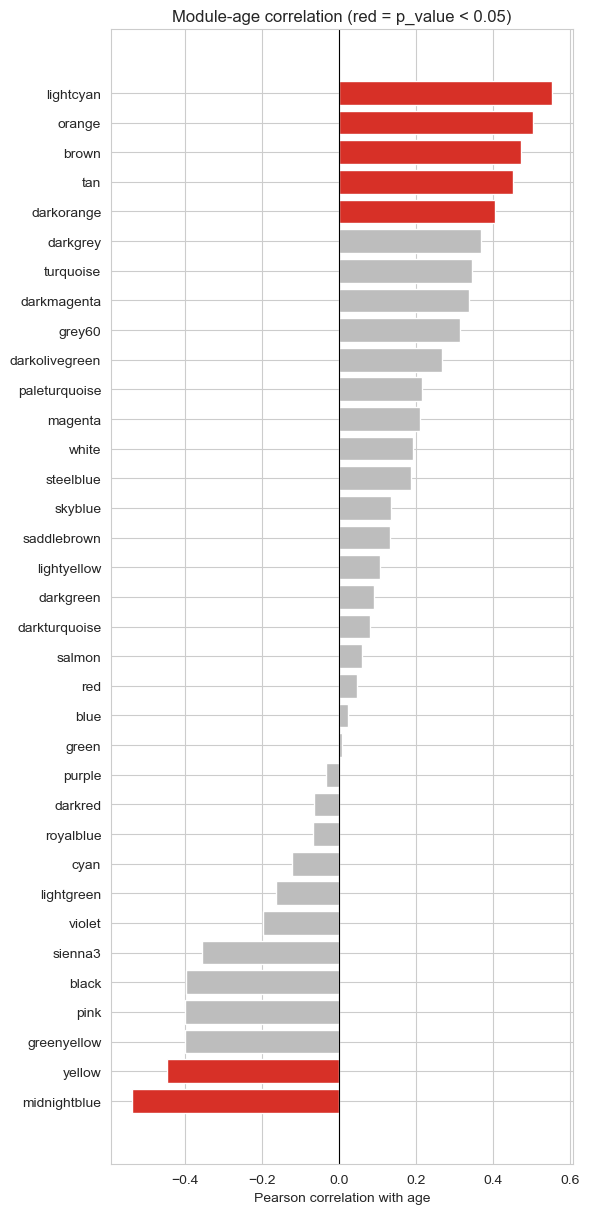

In [27]:
m = module_age.copy().sort_values('correlation')
m['significant'] = m['p_value'] < 0.05

plt.figure(figsize=(6, max(3, 0.35 * len(m))))
colors = m['significant'].map({True: '#d73027', False: '#bdbdbd'})
plt.barh(m['module'], m['correlation'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson correlation with age')
plt.title('Module-age correlation (red = p_value < 0.05)')
plt.tight_layout()
plt.savefig('barplot_correlation.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


### 6.2 Hub gene x cell type kME heatmap

For a chosen age-associated module, a heatmap of kME (module membership) for its hub genes across
the cell types they were identified in -- mirrors the per-module heatmaps you already build in R,
now colored by kME instead of enrichment.


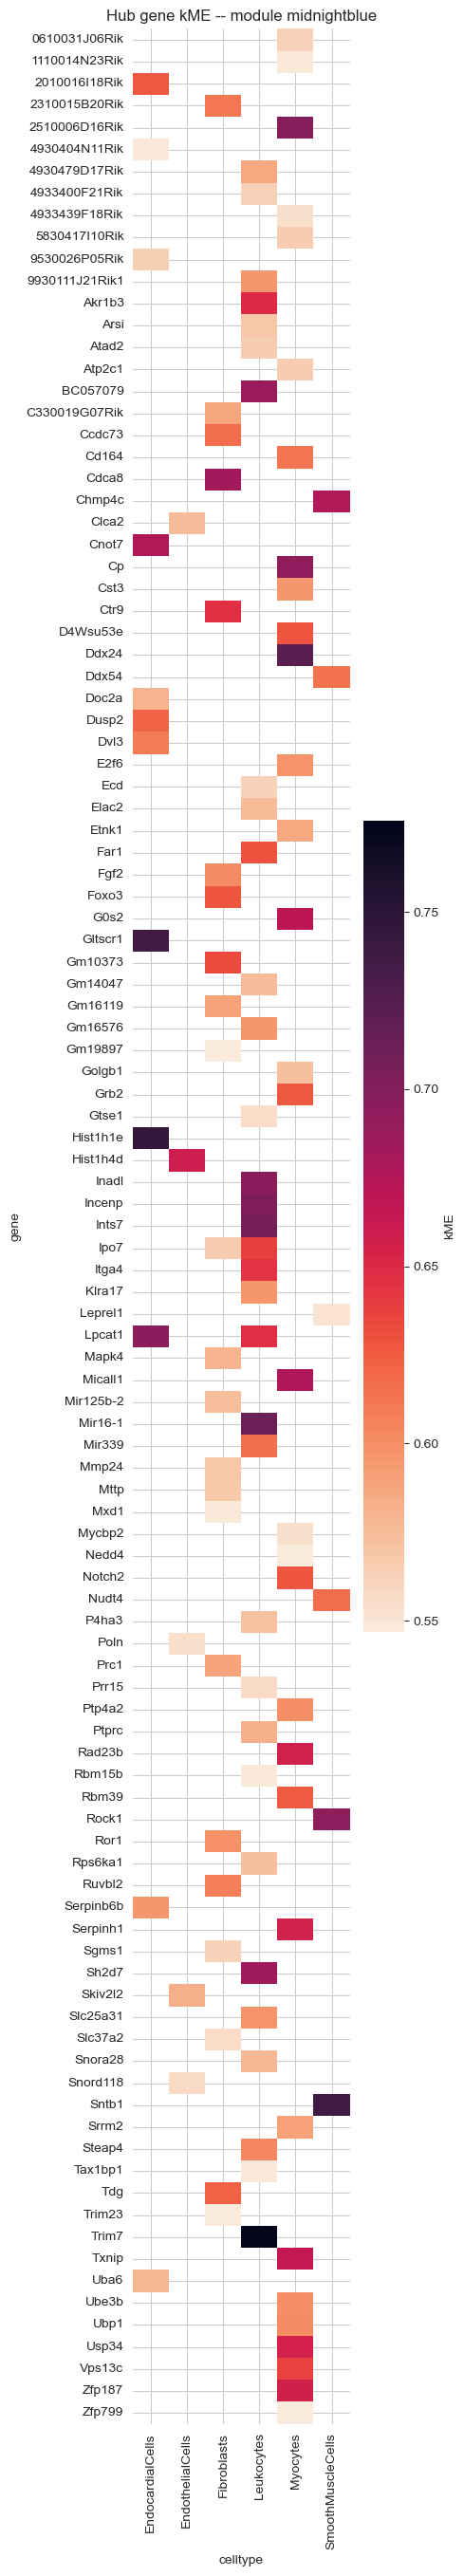

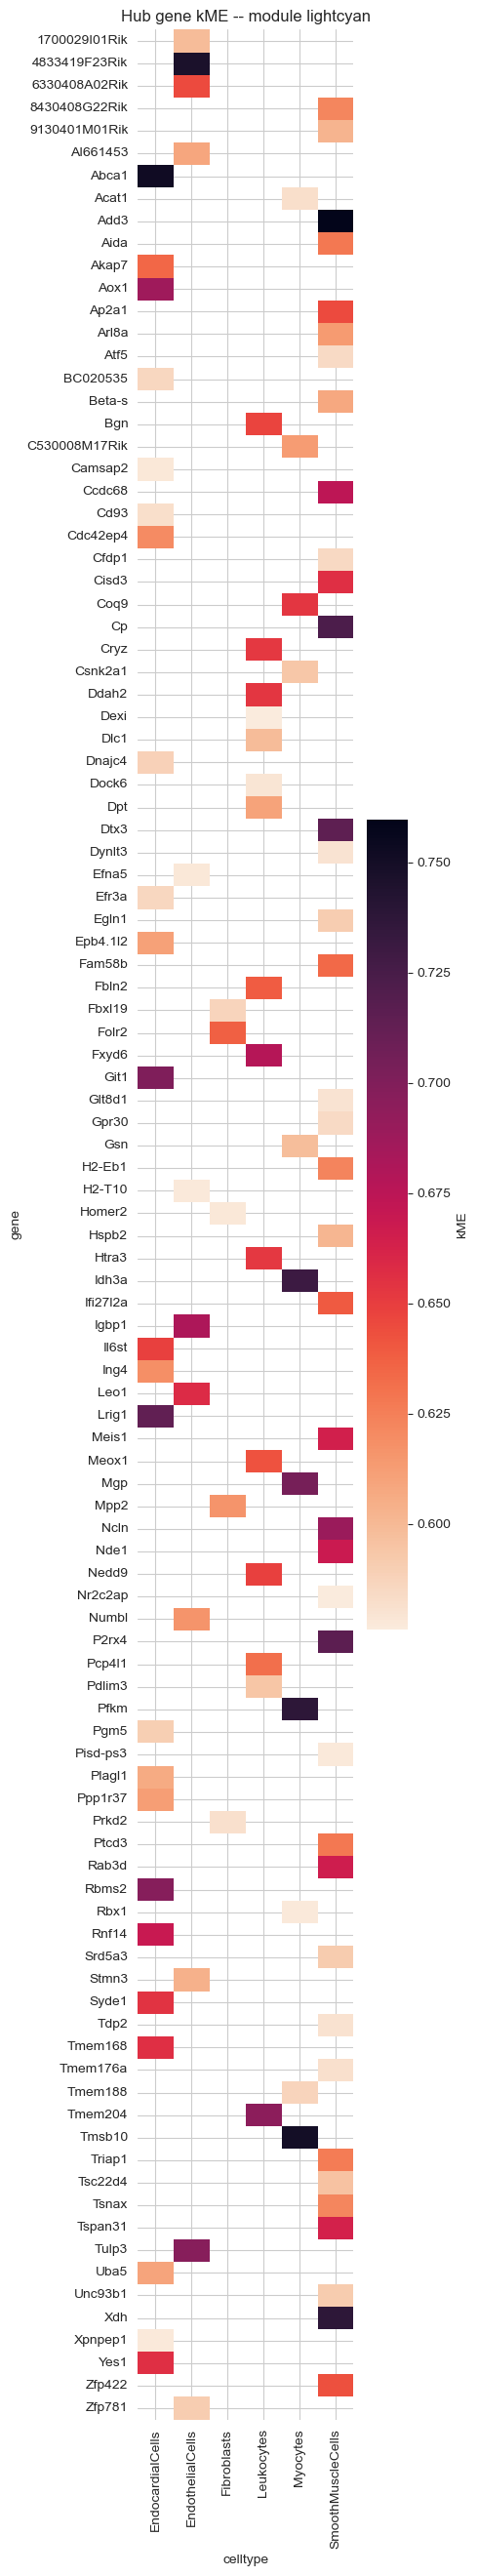

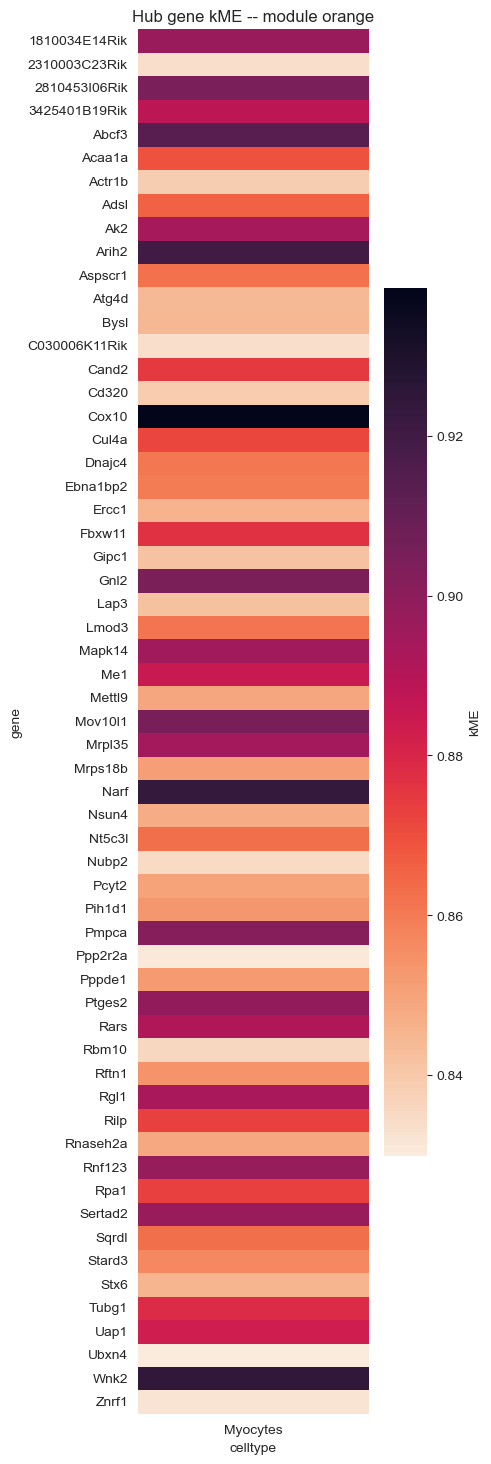

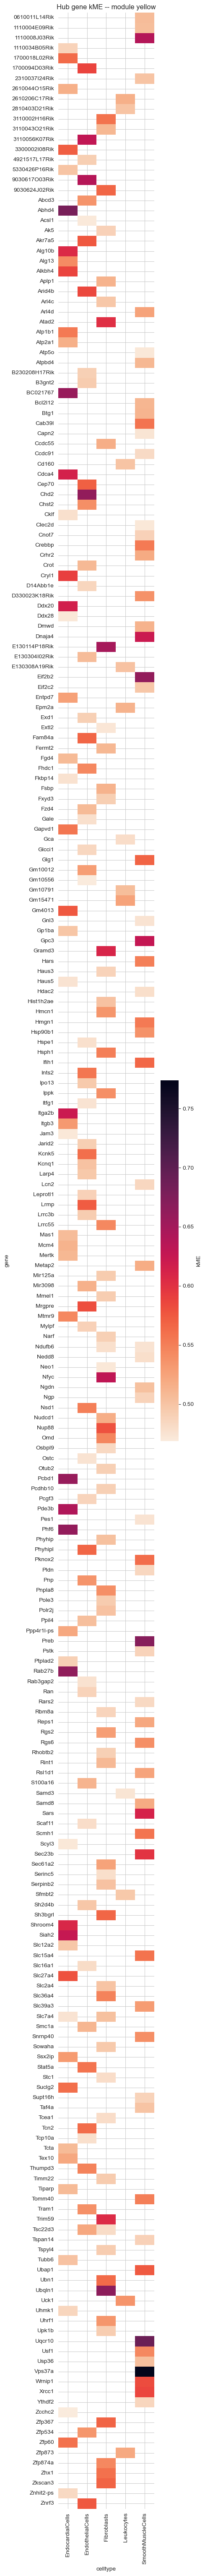

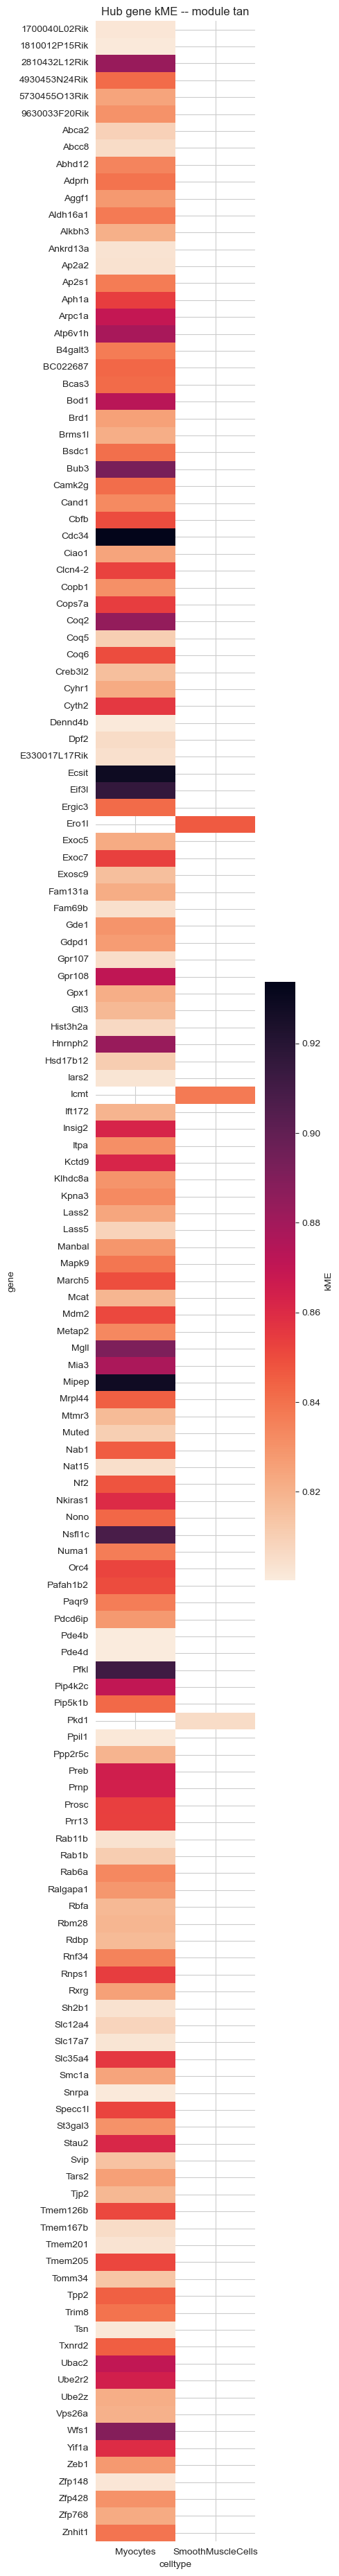

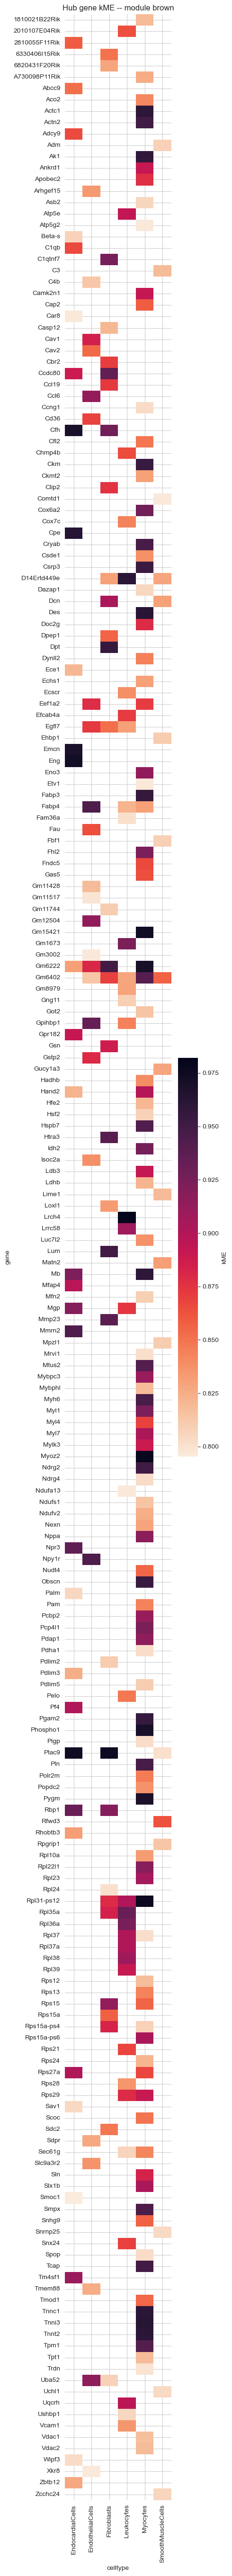

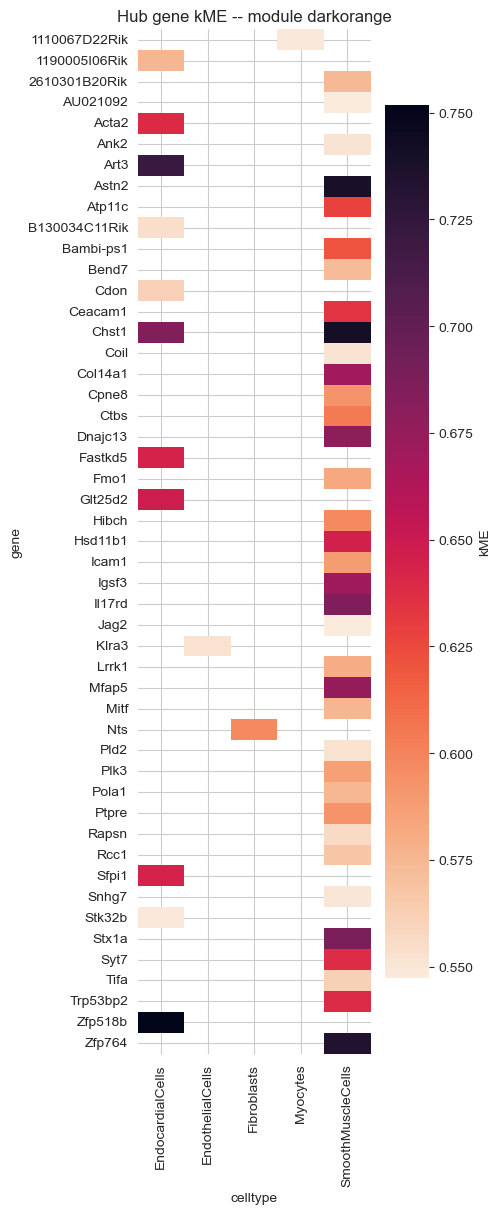

In [28]:
for m in range(len(sig_modules)):
    module_to_inspect = sig_modules[m] if len(sig_modules) > 0 else hub_genes['module'].iloc[0]
    
    hg = hub_genes[hub_genes['module'] == module_to_inspect]
    kme_mat = hg.pivot_table(index='gene', columns='celltype', values='kME', aggfunc='mean')
    
    plt.figure(figsize=(5, max(4, 0.25 * len(kme_mat))))
    sns.heatmap(kme_mat, cmap='rocket_r', cbar_kws={'label': 'kME'})
    plt.title(f'Hub gene kME -- module {module_to_inspect}')
    plt.tight_layout()
    plt.savefig(f'Hub gene kME -- module {module_to_inspect}', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()


### 6.3 Focused views on age-relevant interactions

Dotplot and circle plot restricted to interactions whose ligand or receptor belongs to an
age-associated module.


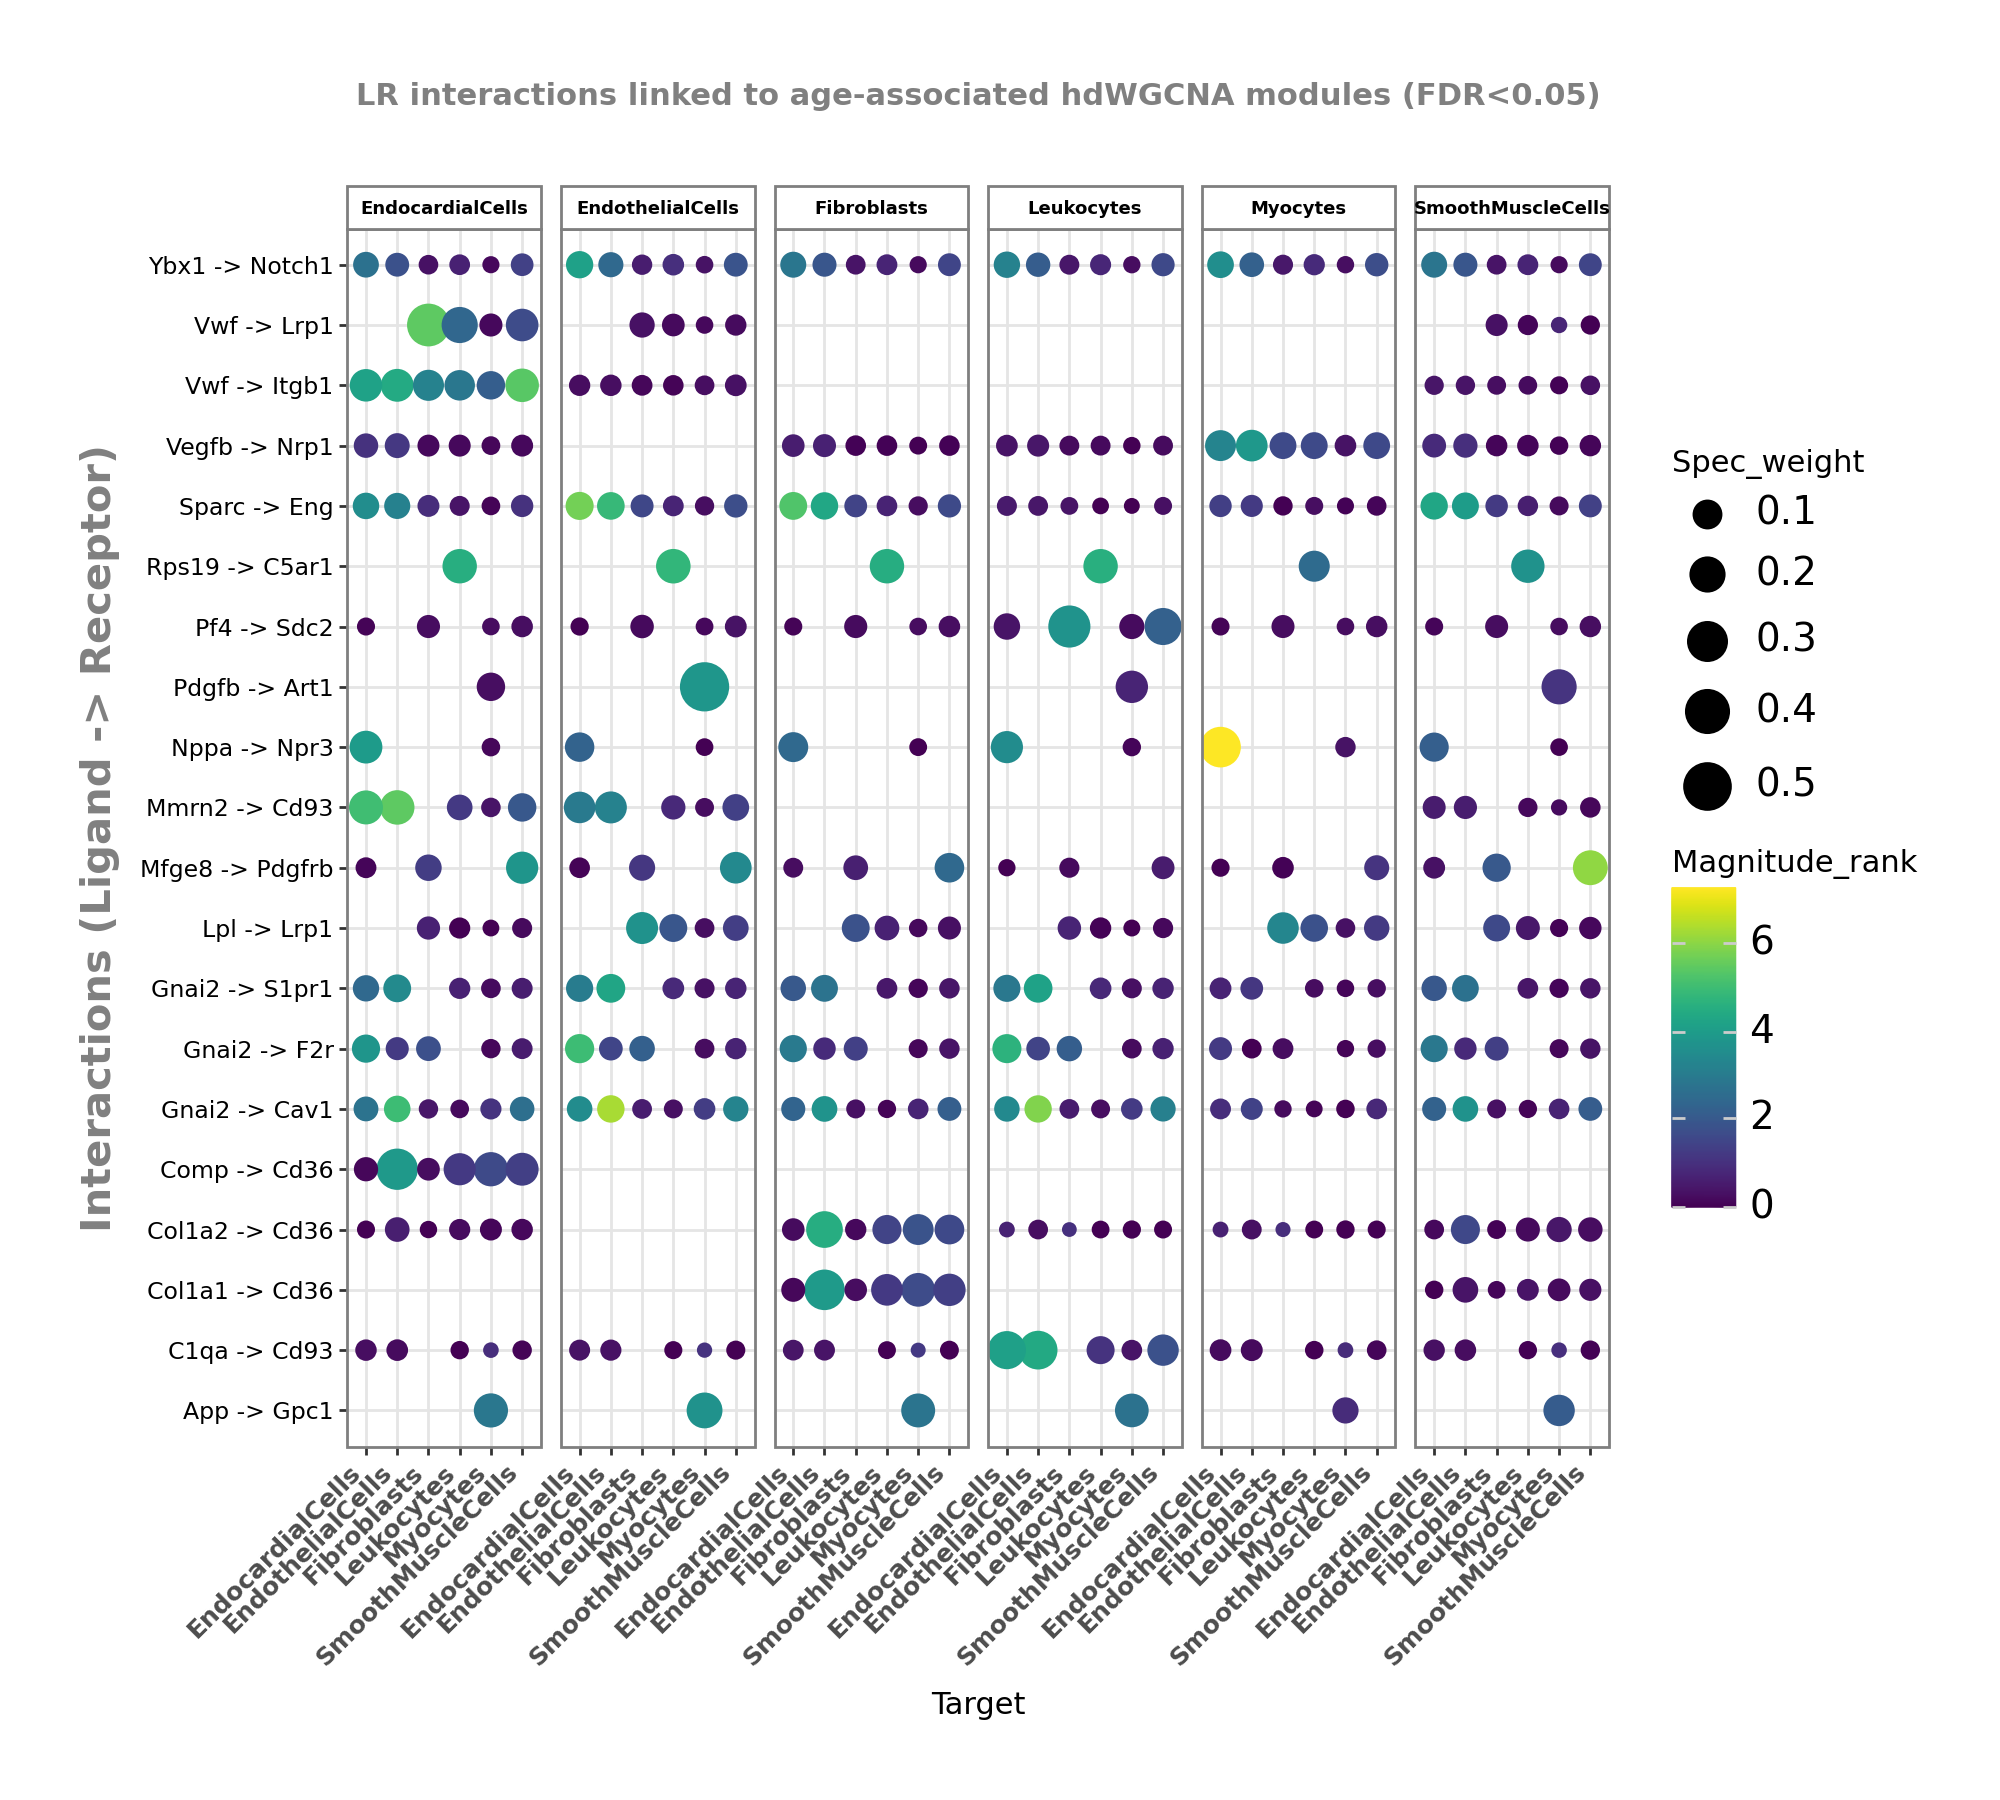

In [37]:

top_pairs = (liana_age_relevant
    .drop_duplicates(['ligand_complex', 'receptor_complex'])
    .head(20)[['ligand_complex', 'receptor_complex']]
    .apply(tuple, axis=1).tolist())

top_pairs_set = set(top_pairs)


liana_df = adata.uns['liana_res'].copy()


liana_df_filtered = liana_df[
    liana_df.apply(lambda r: (r['ligand_complex'], r['receptor_complex']) in top_pairs_set, axis=1)
].copy()


p_age_dot = (
    li.pl.dotplot(
        liana_res=liana_df_filtered,
        colour='magnitude_rank', 
        inverse_colour=True,
        size='spec_weight', 
        inverse_size=False,
        figure_size=(10, 9),  
    ) 
    + p9.ggtitle('LR interactions linked to age-associated hdWGCNA modules (FDR<0.05)')
    + p9.theme(
        plot_title=p9.element_text(size=11, face='bold', margin={'b': 15, 't': 10}),
        axis_text_x=p9.element_text(rotation=45, hjust=1, vjust=1, size=9),
        axis_text_y=p9.element_text(size=8.5),
        strip_text=p9.element_text(size=6.5, face='bold'),
        plot_margin=0.04
    )
)

display(p_age_dot)

p_age_dot.save(
    'liana_dotplot_hdwgcna.pdf', 
    dpi=300, 
    width=10, 
    height=9, 
    limitsize=False
)

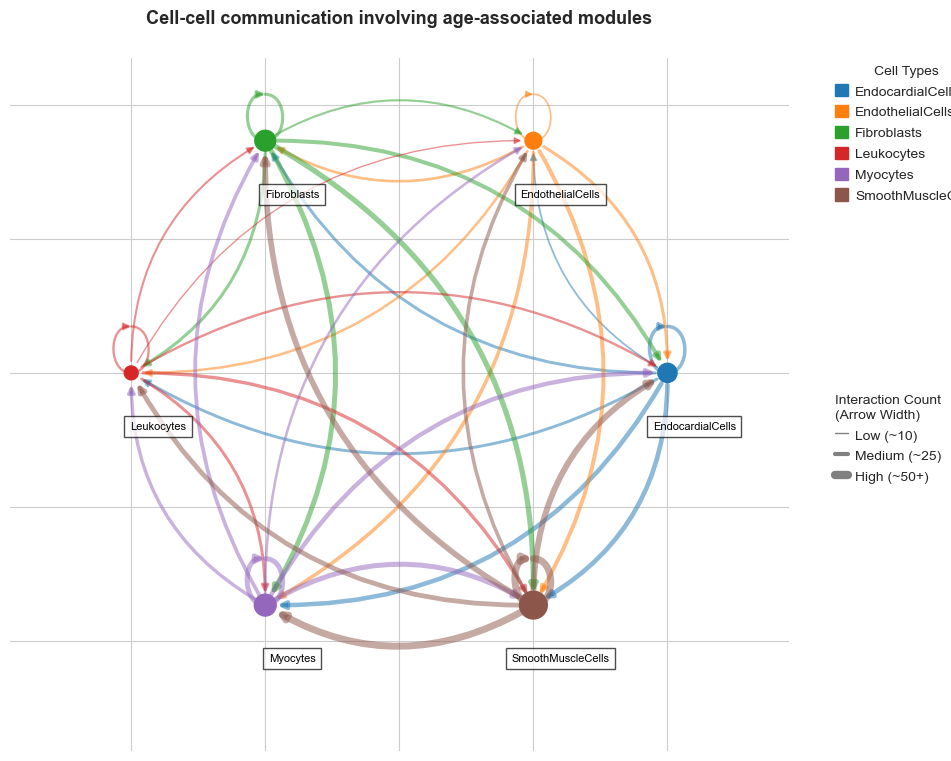

In [30]:

adata.uns['liana_res_age'] = liana_annot[liana_annot['age_relevant']].copy()


li.pl.circle_plot(
    adata,
    groupby=groupby,
    uns_key='liana_res_age',
    score_key='magnitude_rank',
    inverse_score=True,
    pivot_mode='counts',
    figure_size=(12, 9),
)


cell_types = adata.obs[groupby].cat.categories

if f'{groupby}_colors' in adata.uns:
    colors = adata.uns[f'{groupby}_colors']
else:
    colors = plt.cm.tab10.colors[: len(cell_types)]

cell_handles = [
    mpatches.Patch(color=colors[i], label=ct) for i, ct in enumerate(cell_types)
]

leg1 = plt.legend(
    handles=cell_handles,
    title='Cell Types',
    bbox_to_anchor=(1.05, 1.0),
    loc='upper left',
    frameon=False,
)
plt.gca().add_artist(leg1)  # Mantiene activa leg1 al añadir leg2


width_handles = [
    mlines.Line2D([], [], color='gray', linewidth=1, label='Low (~10)'),
    mlines.Line2D([], [], color='gray', linewidth=3, label='Medium (~25)'),
    mlines.Line2D([], [], color='gray', linewidth=6, label='High (~50+)'),
]

leg2 = plt.legend(
    handles=width_handles,
    title='Interaction Count\n(Arrow Width)',
    bbox_to_anchor=(1.05, 0.45),
    loc='center left',
    frameon=False,
)


plt.title(
    'Cell-cell communication involving age-associated modules', 
    fontsize=13, 
    fontweight='bold', 
    pad=25
)

plt.savefig(
    'liana_circle_plot_age_relevant.pdf', 
    format='pdf', 
    bbox_inches='tight', 
    dpi=300
)

plt.show()

## 7. Multi-context per mouse + Tensor-cell2cell (adapted from `liana_c2c.html`)

In the original tutorial the "context" is `stim` vs. `ctrl` (stimulation). Here the natural context
is **mouse age** (`age`), and each "sample" is an individual mouse (`sample_id`) -- exactly the same
design you used for pseudobulk (mouse x cell type).

**On the missing-value errors:** this tensor is built from `adata` (real single-cell counts,
log-normalized in Section 2.1) -- it should **not** reuse the WGCNA pseudobulk matrix, which was
gene-filtered (grey module removed) and age-mean-imputed specifically so hdWGCNA's correlation
network could run without NAs. That matrix is a WGCNA-internal artifact; feeding age-imputed values
into a tool that then estimates age-associated patterns (tensor-cell2cell) would be circular and
would bias the result. Keeping the export as real per-cell expression (Section 2) is correct.

The missing values you're hitting here have a different, expected cause: `by_sample` computes a
score independently **per mouse**, and any (mouse, cell type) combination with too few cells simply
has no score -- which becomes `NaN` in the tensor. With only 4 cell types and rarer populations like
`Leukocytes`, some mice are very likely under-represented. Section 7.0 below checks this directly and
lets you filter or choose how the tensor should handle it, instead of ending up with random `NaN`
errors partway through the pipeline.


### 7.0 Check cell coverage per mouse per cell type (root cause of the missing values)


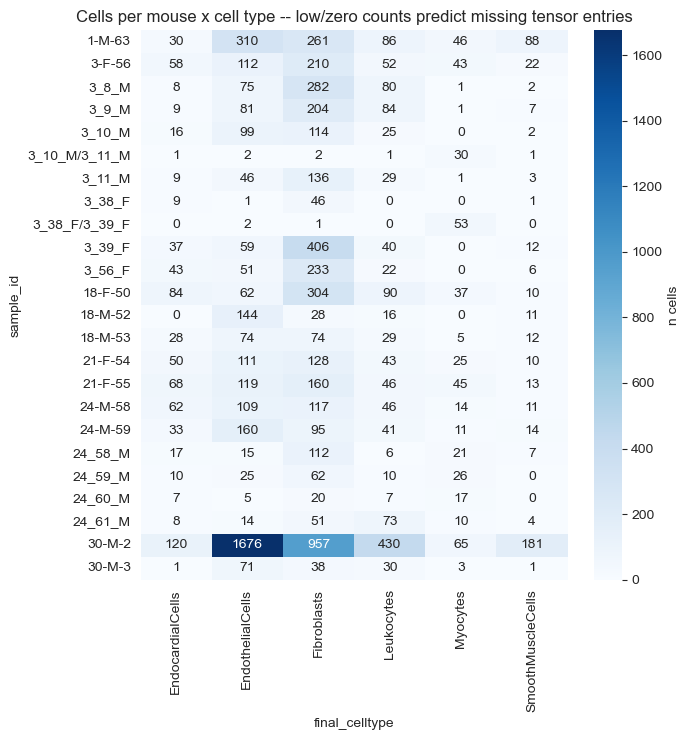

In [31]:
# How many cells does each mouse have per cell type? This is the direct predictor of which
# (mouse, cell type) entries will be missing once we run LIANA+ per sample.
coverage = pd.crosstab(adata.obs[sample_key], adata.obs[groupby])
coverage.loc['TOTAL_MICE_BELOW_THRESHOLD'] = np.nan  # placeholder row, filled below

plt.figure(figsize=(7, max(4, 0.3 * coverage.shape[0])))
sns.heatmap(coverage.drop(index='TOTAL_MICE_BELOW_THRESHOLD'), annot=True, fmt='g',
            cmap='Blues', cbar_kws={'label': 'n cells'})
plt.title('Cells per mouse x cell type -- low/zero counts predict missing tensor entries')
plt.tight_layout()
plt.show()

coverage = coverage.drop(index='TOTAL_MICE_BELOW_THRESHOLD')


In [32]:
# LIANA+'s `by_sample` needs a minimum number of cells per (mouse, cell type) to compute a score
# at all; below that, the entry is skipped (-> NaN downstream). Match this to what you pass as
# `min_cells` below (default shown here: 10).
MIN_CELLS = 10

well_covered = coverage >= MIN_CELLS
n_types_per_mouse = well_covered.sum(axis=1)

print(f"(mouse, cell type) combinations below {MIN_CELLS} cells: {(~well_covered).values.sum()} "
      f"out of {well_covered.size}")
print(well_covered.sum(axis=0).rename('n_mice_above_threshold'))
print()
print("Cell types passing the threshold, per mouse:")
print(n_types_per_mouse.sort_values())


(mouse, cell type) combinations below 10 cells: 44 out of 144
final_celltype
EndocardialCells     14
EndothelialCells     20
Fibroblasts          22
Leukocytes           19
Myocytes             14
SmoothMuscleCells    11
Name: n_mice_above_threshold, dtype: int64

Cell types passing the threshold, per mouse:
sample_id
3_38_F           1
3_10_M/3_11_M    1
3_38_F/3_39_F    1
24_60_M          2
3_11_M           3
3_8_M            3
30-M-3           3
3_9_M            3
18-M-52          4
24_58_M          4
3_56_F           4
3_10_M           4
24_61_M          4
3_39_F           5
18-M-53          5
24_59_M          5
21-F-55          6
21-F-54          6
18-F-50          6
3-F-56           6
1-M-63           6
24-M-59          6
24-M-58          6
30-M-2           6
dtype: int64


In [33]:
# Mice with only ONE well-covered cell type must be dropped: the log2FC method (part of the
# default consensus) compares each cell type against "the rest of the cells in that mouse", and
# divides by the number of "rest" cells -- if a mouse has cells of only one type, "rest" is empty
# and log2FC raises `ZeroDivisionError`. Keeping mice with >=2 well-covered cell types guarantees
# "rest" is never empty. (The safe wrappers in Section 2 also catch this if it still happens, but
# filtering here avoids losing that mouse's data for every OTHER cell type too.)
well_covered_mice = n_types_per_mouse[n_types_per_mouse >= 2].index
print(f"Mice kept (>=2 well-covered cell types): {len(well_covered_mice)} / {coverage.shape[0]}")

adata_tensor = adata[adata.obs[sample_key].isin(well_covered_mice)].copy()

# Stricter alternative, if you want a denser tensor (fewer NaNs) at the cost of dropping more mice
# -- requires ALL 4 cell types to be well covered in every mouse kept:
# fully_covered_mice = n_types_per_mouse[n_types_per_mouse == coverage.shape[1]].index
# adata_tensor = adata[adata.obs[sample_key].isin(fully_covered_mice)].copy()


Mice kept (>=2 well-covered cell types): 21 / 24


In [34]:
run_rank_aggregate_by_sample_safe(
    adata_tensor,
    groupby=groupby,
    resource_name='mouseconsensus',   # mouse
    sample_key=sample_key,
    min_cells=MIN_CELLS,
    use_raw=False,
    layer='lognorm',
    verbose=True,
    n_perms=None,          # skip permutations for speed
    return_all_lrs=True,   # keep all LR pairs, not just those passing expr_prop
)

adata_tensor.uns['liana_res'].sort_values('magnitude_rank').head(10)


Now running: 30-M-3: 100%|██████████| 21/21 [01:18<00:00,  3.75s/it] 


,sample_id,source,target,ligand_complex,receptor_complex,lr_means,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,magnitude_rank
1018860,30-M-2,Myocytes,EndocardialCells,Nppa,Npr3,2.744801,7.477739,3.203928,3.039330,0.382296,0.923151,3.084382e-09
0,1-M-63,Myocytes,EndocardialCells,Nppa,Npr3,2.634345,6.925622,2.925657,2.687894,0.310798,0.914034,3.878110e-09
409909,18-F-50,Myocytes,EndocardialCells,Nppa,Npr3,2.663767,7.087988,1.709028,2.325198,0.206790,0.913697,4.184198e-09
644293,21-F-55,Myocytes,EndocardialCells,Nppa,Npr3,2.587633,6.693300,1.443160,1.967316,0.166967,0.909642,4.318716e-09
85176,3-F-56,Myocytes,EndocardialCells,Nppa,Npr3,2.631462,6.922185,1.846937,2.377038,0.230162,0.910550,4.517970e-09
569701,21-F-54,Myocytes,EndocardialCells,Nppa,Npr3,2.598974,6.734622,1.628071,2.171929,0.195008,0.909518,4.810868e-09
298513,3_39_F,EndothelialCells,EndocardialCells,H2-K1,Aplp2,1.857679,3.448726,0.819952,0.499486,0.064169,0.886085,5.534741e-09
793369,24-M-59,Myocytes,EndocardialCells,Nppa,Npr3,2.632901,6.883326,2.426793,2.952818,0.386976,0.909357,5.595352e-09
724789,24-M-58,Myocytes,EndocardialCells,Nppa,Npr3,2.671107,7.133173,1.817072,2.666481,0.302052,0.909736,5.832260e-09
904189,24_59_M,EndocardialCells,EndocardialCells,H2-K1,Aplp2,1.855962,3.444549,0.881303,0.631339,0.076489,0.875186,7.806883e-09


In [39]:
tensor = li.multi.to_tensor_c2c(
    adata_tensor,
    sample_key=sample_key,
    score_key='magnitude_rank',
    how='outer_cells',      # union of cell types across mice, intersection of LR pairs
    non_expressed_fill=0,   # LR pairs excluded by expr_prop (return_all_lrs=True) -> 0, not NaN
)
tensor.tensor.shape  # (mice, LR interactions, senders, receivers)


100%|██████████| 21/21 [01:06<00:00,  3.17s/it]


(21, 1151, 6, 6)

In [40]:
# Quantify how much of the tensor is still missing after the above. cell2cell's decomposition
# handles a moderate amount of NaN via an internal mask, but a very high fraction (roughly >40-50%)
# tends to make the elbow/rank estimation unstable or push the pipeline to fail outright.
nan_fraction = np.isnan(tensor.tensor).mean()
print(f"Fraction of missing entries in the tensor: {nan_fraction:.1%}")

if nan_fraction > 0.4:
    print(
        "This is quite high. Try one of:\n"
        "  - raise MIN_CELLS filtering less aggressively is unlikely to help; instead consider\n"
        "    lowering MIN_CELLS (e.g. to 5) so more (mouse, cell type) entries get a score,\n"
        "  - switch `how='outer_cells'` to `how='inner'` above, to only keep cell types present\n"
        "    in every mouse (drops rarer types like Leukocytes if they're the main driver), or\n"
        "  - use Option B in the previous cell to drop poorly-covered mice before running LIANA+."
    )


Fraction of missing entries in the tensor: 0.0%


In [41]:
c2c.io.export_variable_with_pickle(tensor, str(DATA_DIR / "tensor_heart_age.pkl"))

# context metadata: mouse (sample_id) -> age
context_dict = adata_tensor.obs[[sample_key, condition_key]].drop_duplicates()
context_dict = dict(zip(context_dict[sample_key].astype(str), context_dict[condition_key].astype(str)))
context_dict = defaultdict(lambda: 'Unknown', context_dict)

tensor_meta = c2c.tensor.generate_tensor_metadata(
    interaction_tensor=tensor,
    metadata_dicts=[context_dict, None, None, None],
    fill_with_order_elements=True,
)


tensor_heart_age.pkl  was correctly saved.


In [42]:
tensor = c2c.analysis.run_tensor_cell2cell_pipeline(
    tensor,
    tensor_meta,
    copy_tensor=True,
    rank=None,                 # None -> estimate optimal rank via elbow analysis (use GPU if you can)
    tf_optimization='regular',
    random_state=0,
    device=device,
    elbow_metric='error',
    smooth_elbow=False,
    upper_rank=min(20, adata_tensor.obs[sample_key].nunique() - 1),
    tf_init='random',
    tf_svd='numpy_svd',
    cmaps=None,
    sample_col='Element',
    group_col='Category',
    output_fig=False,
)


Running Elbow Analysis


100%|██████████| 20/20 [1:08:50<00:00, 206.52s/it]


The rank at the elbow is: 8
Running Tensor Factorization


### 7.0.2 Checkpoint 


In [15]:
import pickle
from pathlib import Path
import pandas as pd

CHECKPOINT_DIR = Path("C:/Data/Sandra Anjo/Luis Grilo/WGCNA/LIANA/checkpoint")
CHECKPOINT_DIR.mkdir(exist_ok=True, parents=True)

# Fix: convertir columnas/indices en StringDtype a object antes de escribir h5ad
def _fix_string_dtypes(df):
    df.index = df.index.astype(str)
    for col in df.columns:
        if pd.api.types.is_string_dtype(df[col]) and not pd.api.types.is_categorical_dtype(df[col]):
            df[col] = df[col].astype(object)
    return df

# Fix adicional: limpiar valores nulos/mixtos en DataFrames dentro de adata.uns (resuelve error en liana_res_age)
def _clean_uns_dfs(uns_dict):
    for k, v in uns_dict.items():
        if isinstance(v, pd.DataFrame):
            v.index = v.index.astype(str)
            for col in v.columns:
                if v[col].dtype == 'object' or pd.api.types.is_string_dtype(v[col]):
                    v[col] = v[col].fillna("").astype(str)
        elif isinstance(v, dict):
            _clean_uns_dfs(v)

# Aplicar las correcciones a obs, var y uns
adata_tensor.obs = _fix_string_dtypes(adata_tensor.obs)
adata_tensor.var = _fix_string_dtypes(adata_tensor.var)
_clean_uns_dfs(adata_tensor.uns)


adata_tensor.write_h5ad(CHECKPOINT_DIR / "adata_tensor_liana_scored.h5ad")


c2c.io.export_variable_with_pickle(tensor, str(CHECKPOINT_DIR / "tensor_decomposed.pkl"))


c2c.io.export_variable_with_pickle(tensor_meta, str(CHECKPOINT_DIR / "tensor_meta.pkl"))


with open(CHECKPOINT_DIR / "context_dict.pkl", "wb") as f:
    pickle.dump(dict(context_dict), f)


coverage.to_csv(CHECKPOINT_DIR / "coverage_table.csv")
pd.Series(list(well_covered_mice), name="sample_id").to_csv(
    CHECKPOINT_DIR / "well_covered_mice.csv", index=False
)

print(f"Checkpoint completo guardado en: {CHECKPOINT_DIR.resolve()}")

NameError: name 'adata_tensor' is not defined

### 7.0.3 Recargar el checkpoint (otro día, sin reiniciar desde la Sección 4)

Corre esta celda en vez de las Secciones 4-7.0 si ya tienes un checkpoint guardado. Deja
disponibles `adata_tensor`, `tensor`, `tensor_meta`, `context_dict`, `factors_dict` y
`lr_loadings`, listos para la Sección 7.1 en adelante.

In [23]:
import pickle
from collections import defaultdict

CHECKPOINT_DIR = Path("C:/Users/olaia/Desktop/WGCNA_results/LIANA/checkpoint")

adata_tensor = sc.read_h5ad(CHECKPOINT_DIR / "adata_tensor_liana_scored.h5ad")
tensor = c2c.io.load_variable_with_pickle(str(CHECKPOINT_DIR / "tensor_decomposed.pkl"))
tensor_meta = c2c.io.load_variable_with_pickle(str(CHECKPOINT_DIR / "tensor_meta.pkl"))

with open(CHECKPOINT_DIR / "context_dict.pkl", "rb") as f:
    context_dict = defaultdict(lambda: 'Unknown', pickle.load(f))

factors_dict = tensor.factors
lr_loadings = factors_dict['Ligand-Receptor Pairs']

print("Checkpoint recargado. Puedes ir directo a la Sección 7.1 (galería de factores).")

Checkpoint recargado. Puedes ir directo a la Sección 7.1 (galería de factores).


### 7.1 Factor exploration gallery

Full factor summary plot, context boxplots (which factor separates mice by age), a CCC network for
the age-associated factor, an LR-loadings heatmap across all factors, and sender/receiver loading
barplots.


### 7.1 Factor exploration gallery


In [24]:
import matplotlib
from IPython.display import display

print("Current matplotlib backend:", matplotlib.get_backend())
%matplotlib inline
TENSOR_OUTPUT_DIR = Path("C:/Data/Sandra Anjo/Luis Grilo/WGCNA/LIANA/tensor_c2c_outputs")
TENSOR_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

def show_c2c_plot(result, pdf_name=None):
    """cell2cell's plotting functions return a fig, a (fig, ax(es)) tuple, or None depending on
    the function/version. This normalizes all of those into a plt.show() + explicit display(fig)
    (robust fallback if the kernel's inline backend isn't picking up the figure on its own), and
    optionally saves the figure as a PDF into TENSOR_OUTPUT_DIR."""
    fig = result[0] if isinstance(result, tuple) else result
    plt.show()
    if fig is not None:
        display(fig)
        if pdf_name is not None:
            out_path = TENSOR_OUTPUT_DIR / pdf_name
            fig.savefig(out_path, format='pdf', bbox_inches='tight')
            print(f"Saved: {out_path}")
    return result


Current matplotlib backend: inline


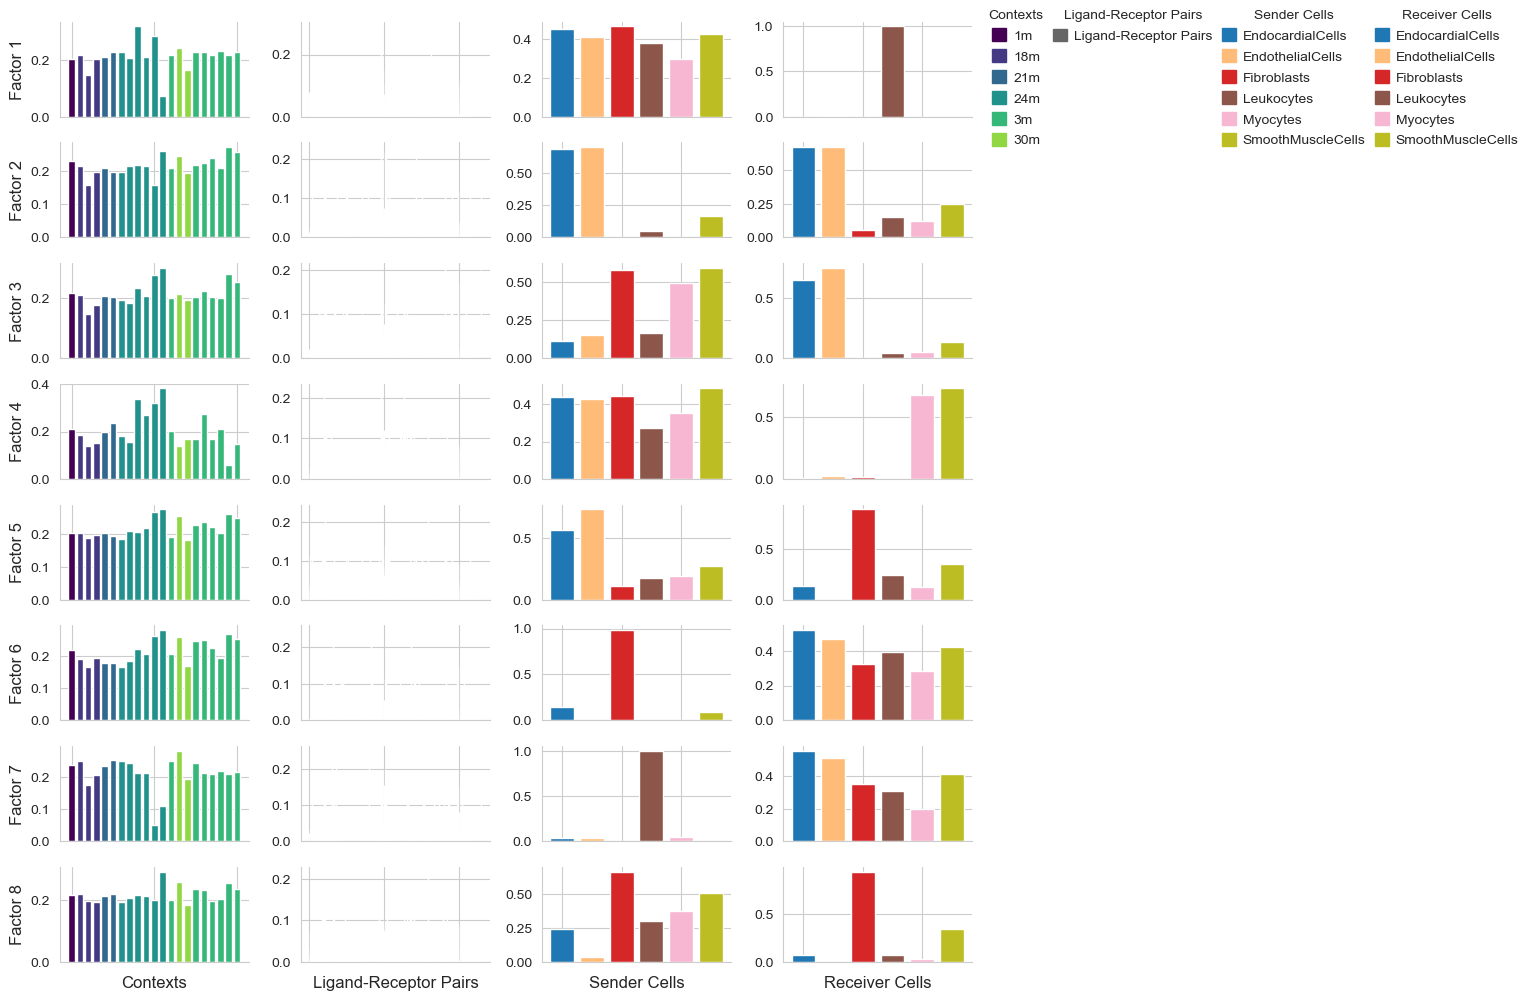

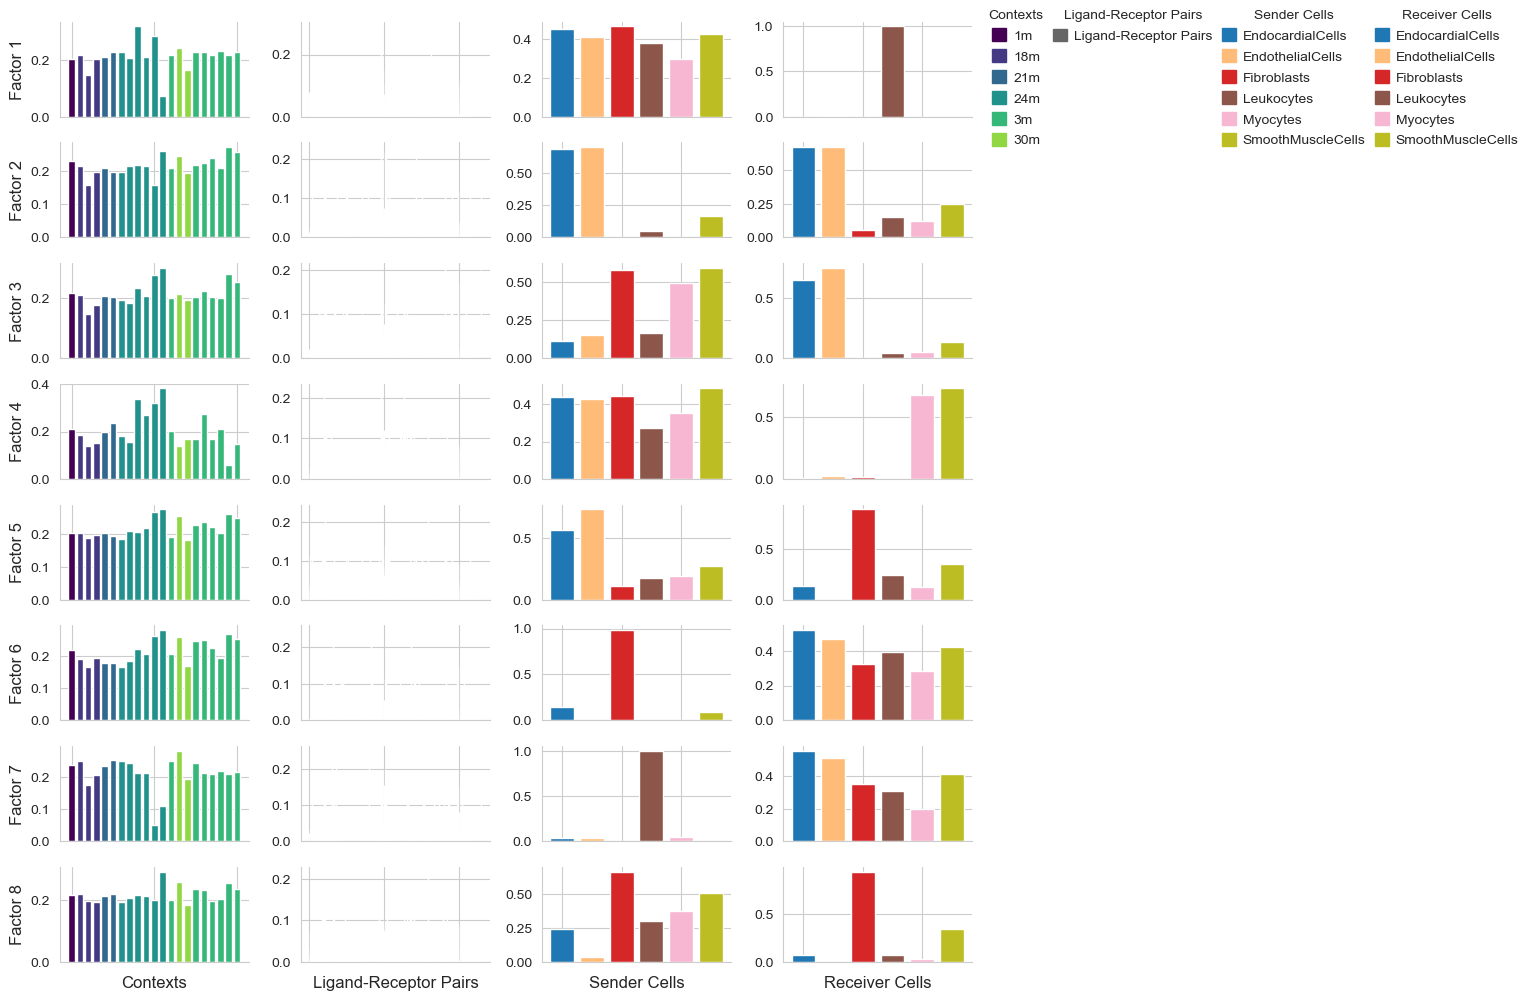

Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\01_tensor_factors_plot.pdf
Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\factor_loadings_Contexts.csv  (shape=(21, 8))
Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\factor_loadings_Ligand-Receptor_Pairs.csv  (shape=(1151, 8))
Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\factor_loadings_Sender_Cells.csv  (shape=(6, 8))
Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\factor_loadings_Receiver_Cells.csv  (shape=(6, 8))


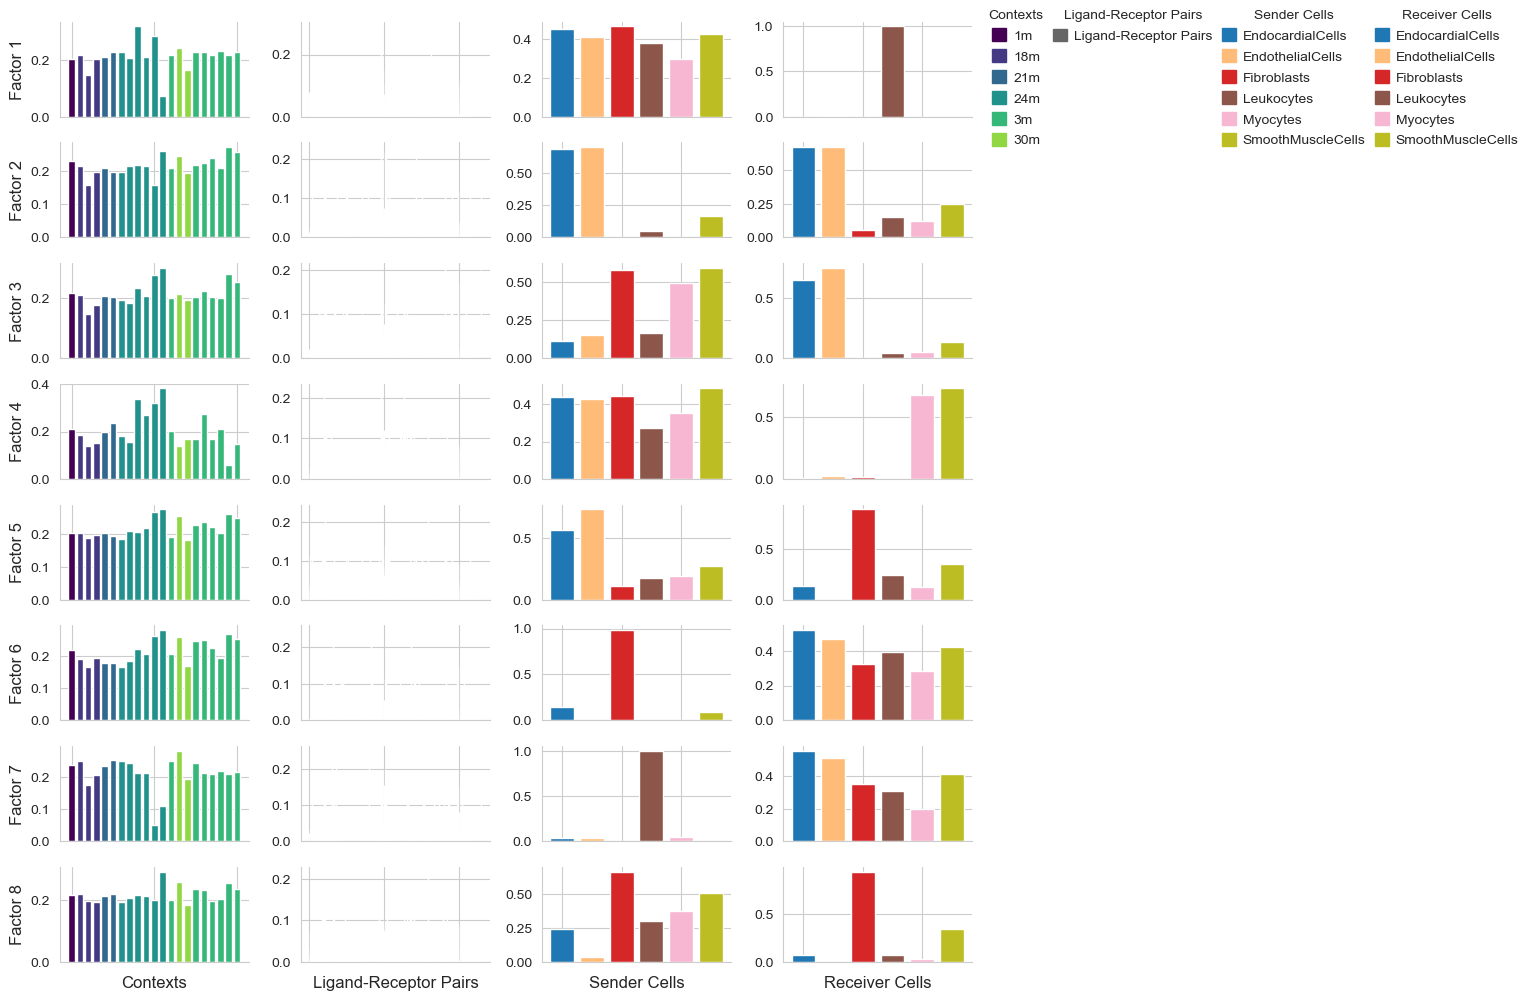

In [49]:
factors_dict = tensor.factors

result = c2c.plotting.tensor_factors_plot(
    interaction_tensor=tensor,
    metadata=tensor_meta,
    sample_col='Element',
    group_col='Category',
    meta_cmaps=['viridis', 'Dark2_r', 'tab20', 'tab20'],
    fontsize=10,
)
_ = show_c2c_plot(result, pdf_name="01_tensor_factors_plot.pdf")

# Export every dimension's loadings -- the numbers behind the plot above
for dim_name, loadings in factors_dict.items():
    csv_path = TENSOR_OUTPUT_DIR / f"factor_loadings_{dim_name.replace(' ', '_')}.csv"
    loadings.to_csv(csv_path)
    print(f"Saved: {csv_path}  (shape={loadings.shape})")

_ = show_c2c_plot(result)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

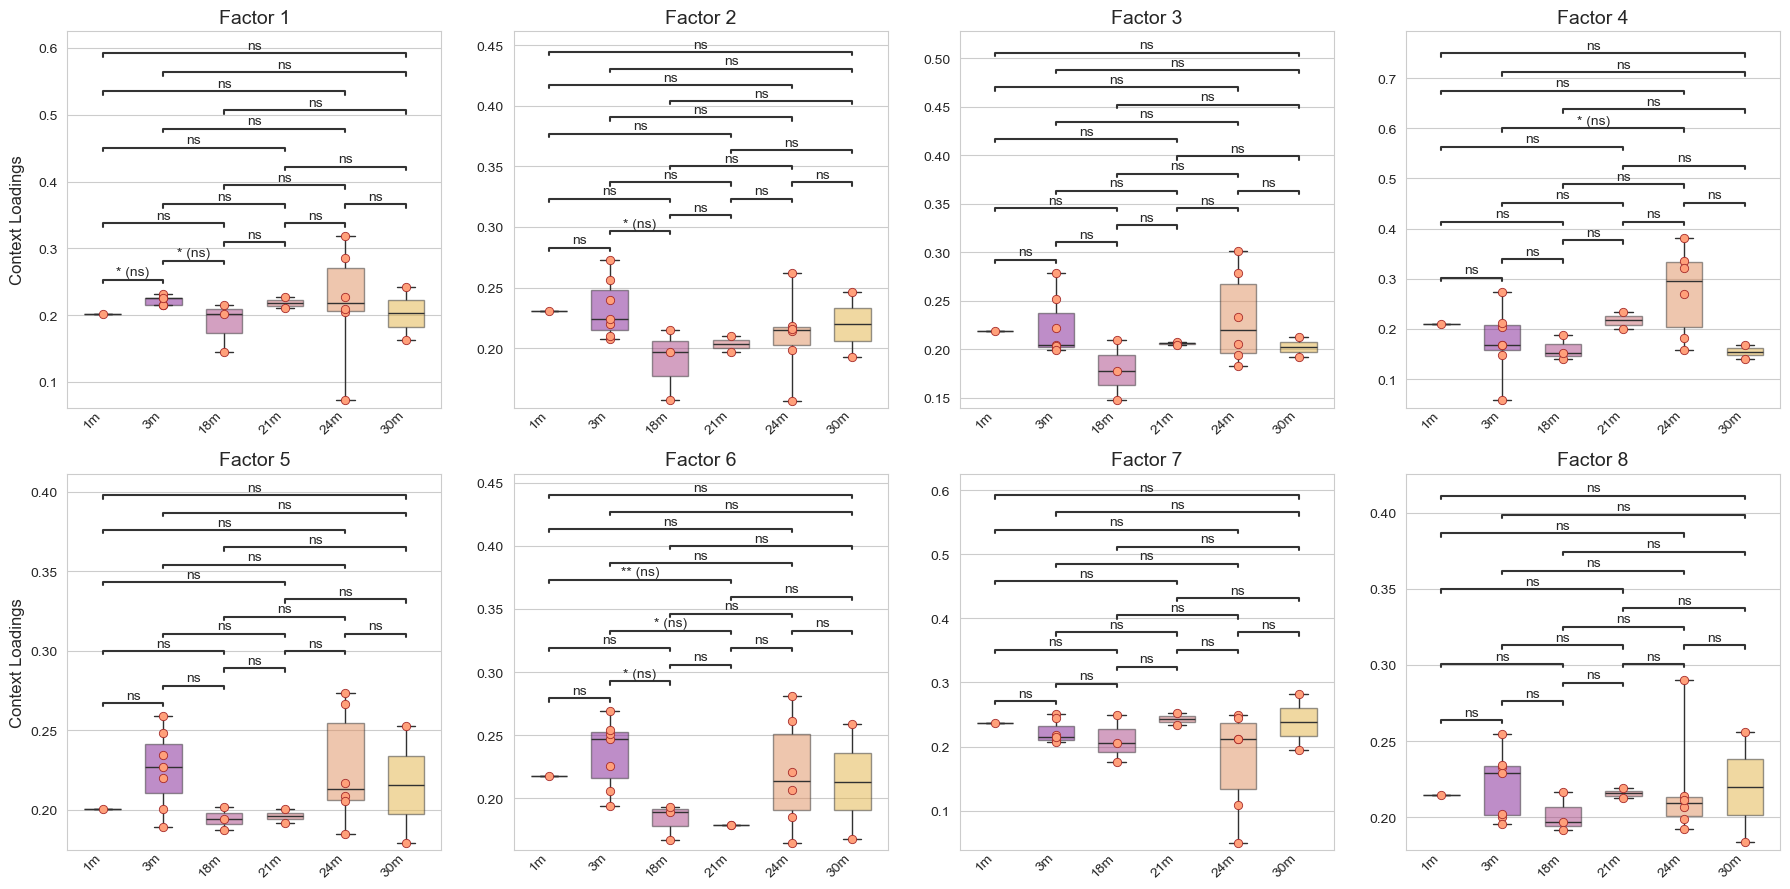

In [50]:
import matplotlib.pyplot as plt

# 1. Orden cronológico con todos los grupos presentes (incluyendo '21m')
age_order = ["1m", "3m", "18m", "21m", "24m", "30m"]

# 2. Desempaquetar la tupla (fig, axes)
fig, axes = c2c.plotting.context_boxplot(
    context_loadings=factors_dict["Contexts"],
    metadict=context_dict,
    group_order=age_order,
    nrows=2,
    figsize=(18, 9),
    statistical_test="t-test_ind",
    pval_correction="fdr_bh",
    cmap="plasma",
    verbose=False,
)


plt.tight_layout()

# 4. Guardar y mostrar
plt.savefig(
    TENSOR_OUTPUT_DIR / "02_context_boxplot_clean.pdf", bbox_inches="tight"
)
plt.savefig(
    TENSOR_OUTPUT_DIR / "02_context_boxplot_clean.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

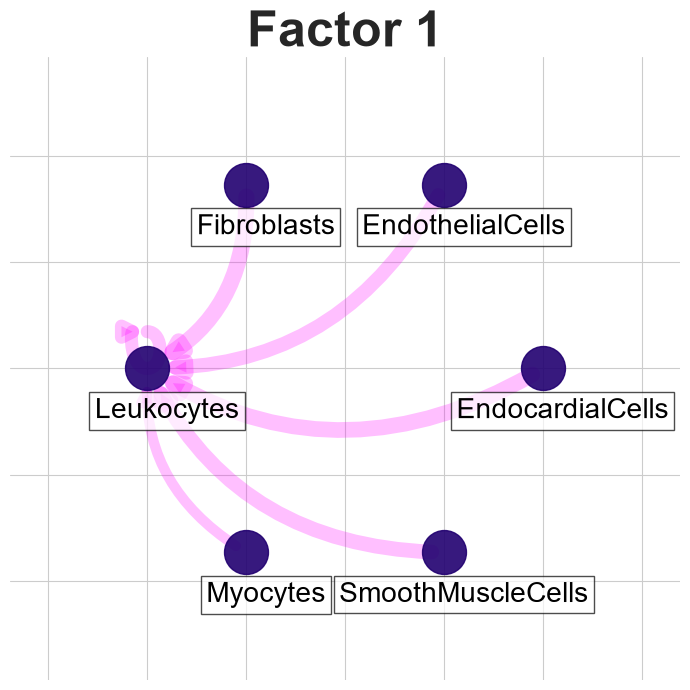

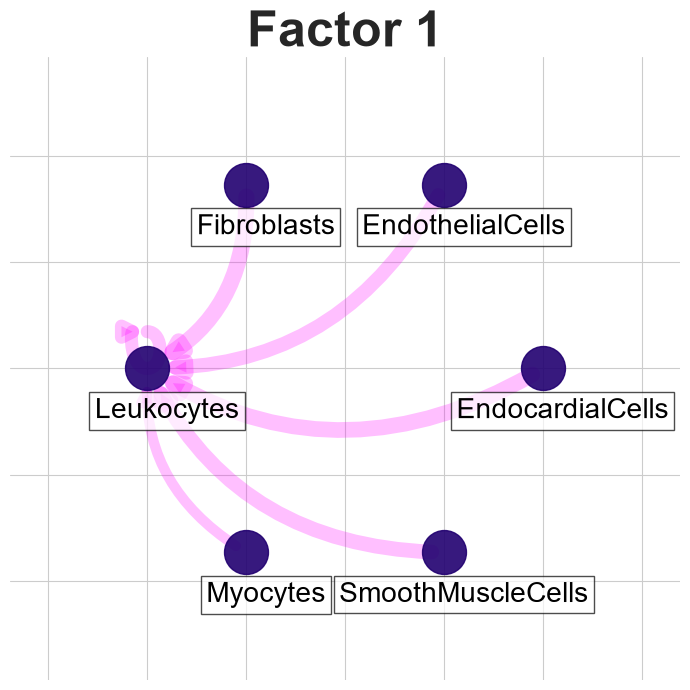

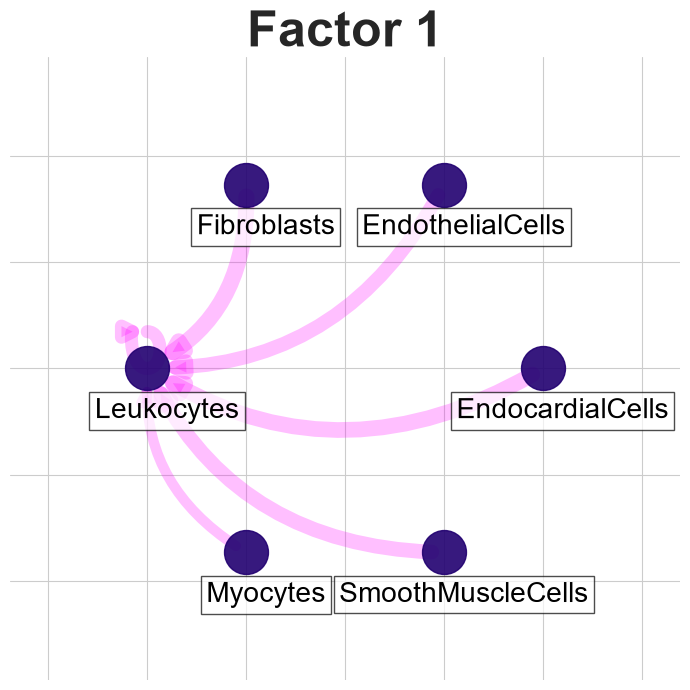

Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\03_ccc_network_Factor_1.pdf
Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\ccc_network_edges_Factor_1.csv  (36 edges)


In [41]:
# Pick the age-related factor from the boxplot above (the one that best separates 'age')
age_factor = 'Factor 1'  # <-- update after inspecting the boxplot
age_factor_tag = age_factor.replace(' ', '_')

# CCC network for that factor: which cell types drive the age-associated communication pattern
result = c2c.plotting.ccc_networks_plot(
    factors_dict,
    included_factors=[age_factor],
    network_layout='circular',
    ccc_threshold=0.05,
    nrows=1,
    panel_size=(7, 7),
)
_ = show_c2c_plot(result, pdf_name=f"03_ccc_network_{age_factor_tag}.pdf")

# Export the same network as a sender->receiver edge list (adjacency matrix melted to long format)
networks = c2c.analysis.tensor_downstream.get_factor_specific_ccc_networks(
    factors_dict, sender_label='Sender Cells', receiver_label='Receiver Cells'
)
adj = networks[age_factor].copy()
adj.index.name = 'sender'
edge_list = adj.reset_index().melt(id_vars='sender', var_name='receiver', value_name='weight')
edge_list = edge_list[edge_list['weight'] > 0].sort_values('weight', ascending=False)
csv_path = TENSOR_OUTPUT_DIR / f"ccc_network_edges_{age_factor_tag}.csv"
edge_list.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}  ({len(edge_list)} edges)")


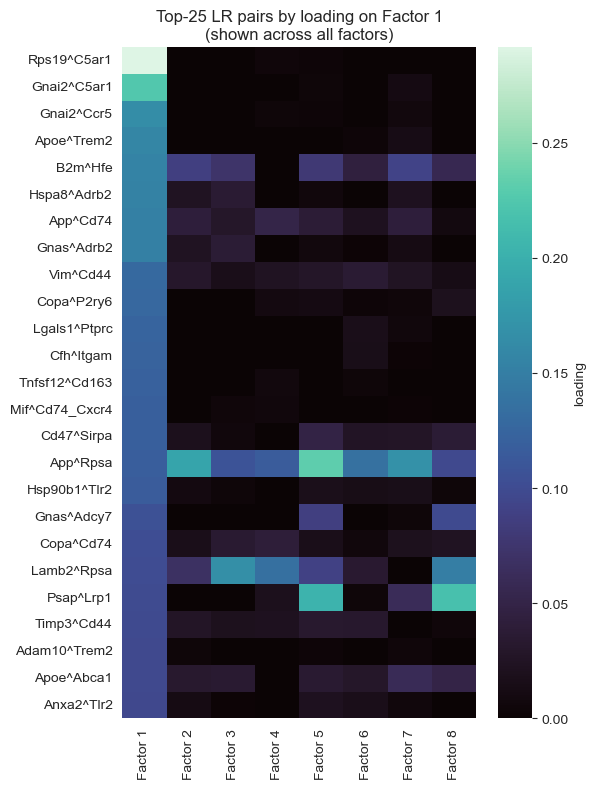

Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\04_top_lr_pairs_Factor_1_heatmap.pdf
Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\top_lr_pairs_Factor_1.csv


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8
Rps19^C5ar1,0.291511,3.889540e-06,3.344801e-18,5.240709e-03,2.382911e-03,6.555943e-05,1.089522e-03,1.066684e-11
Gnai2^C5ar1,0.225063,3.576141e-04,1.654967e-18,3.028300e-04,4.191623e-03,3.139526e-08,1.064820e-02,2.595033e-13
Gnai2^Ccr5,0.164872,5.963783e-05,1.777360e-19,3.654833e-03,2.337477e-03,1.186524e-08,7.315701e-03,1.902993e-13
Apoe^Trem2,0.157538,3.274500e-05,1.490749e-12,3.234181e-16,4.755430e-05,3.401660e-03,1.310510e-02,9.198149e-12
B2m^Hfe,0.154861,8.669793e-02,7.176370e-02,5.287921e-06,7.967218e-02,4.346182e-02,9.220923e-02,5.595435e-02
Hspa8^Adrb2,0.153330,2.306358e-02,3.576990e-02,7.830738e-13,6.364520e-03,7.489951e-04,2.074597e-02,1.897730e-04
App^Cd74,0.152376,4.154890e-02,2.954317e-02,5.108942e-02,3.835769e-02,2.060011e-02,4.208621e-02,8.924147e-03
Gnas^Adrb2,0.151501,2.338524e-02,3.658657e-02,7.817820e-11,6.851168e-03,2.096511e-03,1.141399e-02,1.127010e-05
Vim^Cd44,0.128409,3.019167e-02,1.704825e-02,2.361069e-02,2.779333e-02,3.632143e-02,2.482305e-02,1.350471e-02
Copa^P2ry6,0.126860,7.115221e-05,8.534273e-10,1.018691e-02,1.119575e-02,2.998221e-03,5.041141e-03,2.026744e-02


In [52]:
# Heatmap of LR-pair loadings across ALL factors (top loadings for the age factor)
lr_loadings = factors_dict['Ligand-Receptor Pairs']
top_lr_age_factor = lr_loadings.sort_values(age_factor, ascending=False).head(25)

fig = plt.figure(figsize=(6, 8))
sns.heatmap(top_lr_age_factor, cmap='mako', cbar_kws={'label': 'loading'})
plt.title(f'Top-25 LR pairs by loading on {age_factor}\n(shown across all factors)')
plt.tight_layout()
pdf_path = TENSOR_OUTPUT_DIR / f"04_top_lr_pairs_{age_factor_tag}_heatmap.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {pdf_path}")

top_lr_csv = TENSOR_OUTPUT_DIR / f"top_lr_pairs_{age_factor_tag}.csv"
top_lr_age_factor.to_csv(top_lr_csv)
lr_loadings.to_csv(TENSOR_OUTPUT_DIR / "all_lr_pair_loadings_all_factors.csv")
print(f"Saved: {top_lr_csv}")

top_lr_age_factor


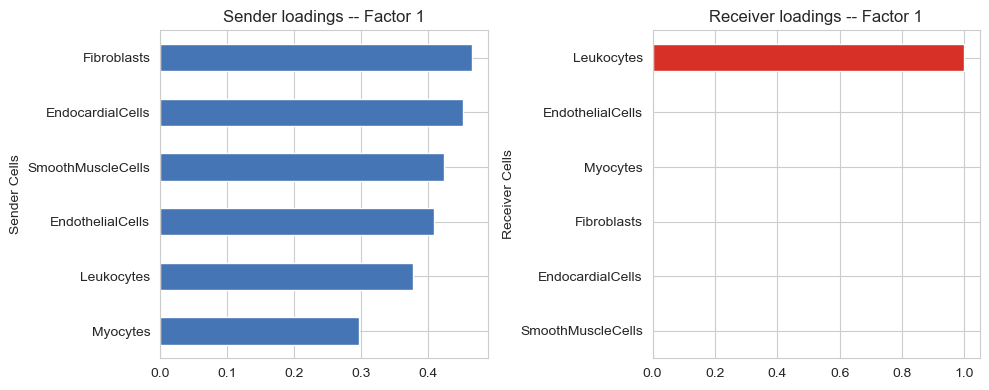

Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\05_sender_receiver_loadings_Factor_1.pdf
Saved: C:\Data\Sandra Anjo\Luis Grilo\WGCNA\LIANA\tensor_c2c_outputs\sender_receiver_loadings_Factor_1.csv


In [53]:
# Sender and receiver cell-type loadings for the age factor
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

factors_dict['Sender Cells'][age_factor].sort_values().plot.barh(ax=axes[0], color='#4575b4')
axes[0].set_title(f'Sender loadings -- {age_factor}')

factors_dict['Receiver Cells'][age_factor].sort_values().plot.barh(ax=axes[1], color='#d73027')
axes[1].set_title(f'Receiver loadings -- {age_factor}')

plt.tight_layout()
pdf_path = TENSOR_OUTPUT_DIR / f"05_sender_receiver_loadings_{age_factor_tag}.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {pdf_path}")

sender_receiver_loadings = pd.concat([
    factors_dict['Sender Cells'][age_factor].rename('sender_loading'),
    factors_dict['Receiver Cells'][age_factor].rename('receiver_loading'),
], axis=1)
csv_path = TENSOR_OUTPUT_DIR / f"sender_receiver_loadings_{age_factor_tag}.csv"
sender_receiver_loadings.to_csv(csv_path)
print(f"Saved: {csv_path}")


## 8. Cross-validation: are the age-factor's top LR pairs enriched in your age-associated modules?

Hypergeometric enrichment test of the genes with the highest loadings on the age-associated factor
against the genes from your hdWGCNA modules significantly correlated with age.


In [54]:
from scipy.stats import hypergeom

def split_lr_index(idx):
    genes = set()
    for pair in idx:
        for g in pair.replace('^', '_').split('_'):
            genes.add(g)
    return genes

top_n = 40
factor_genes = split_lr_index(lr_loadings.sort_values(age_factor, ascending=False).head(top_n).index)

# Universe: all genes that appear in any LR pair of the tensor
universe_genes = split_lr_index(lr_loadings.index)

# Hub genes from age-associated modules (any cell type)
age_module_genes = set(hub_genes.loc[hub_genes['module'].isin(sig_modules), 'gene'])

k = len(factor_genes & universe_genes)                  # observed successes in the sample
K = len(age_module_genes & universe_genes)               # possible successes in the universe
N = len(universe_genes)                                   # universe size
n = len(factor_genes)                                       # sample size

overlap_genes = factor_genes & age_module_genes
pval = hypergeom.sf(len(overlap_genes) - 1, N, K, n)

print(f"Genes in top-{top_n} of {age_factor}: {n}")
print(f"Genes in age-associated modules (LR universe): {K} / {N}")
print(f"Observed overlap: {len(overlap_genes)} genes -> {sorted(overlap_genes)}")
print(f"Hypergeometric enrichment p-value: {pval:.4g}")


Genes in top-40 of Factor 1: 50
Genes in age-associated modules (LR universe): 54 / 612
Observed overlap: 6 genes -> ['Abca1', 'Bgn', 'Cfh', 'Hsp90b1', 'Pld2', 'Ptprc']
Hypergeometric enrichment p-value: 0.272


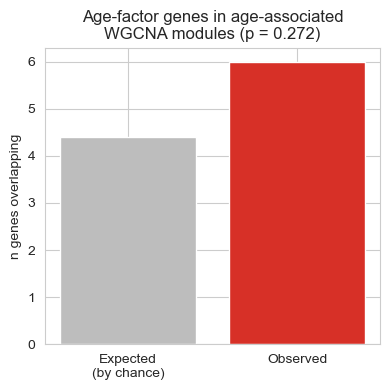

In [55]:
# Visual summary of the overlap test
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Expected\n(by chance)', 'Observed'],
       [n * K / N, len(overlap_genes)],
       color=['#bdbdbd', '#d73027'])
ax.set_ylabel('n genes overlapping')
ax.set_title(f'Age-factor genes in age-associated\nWGCNA modules (p = {pval:.3g})')
plt.tight_layout()
plt.show()


In [56]:
# Final table: LR pairs from the age factor, annotated with hdWGCNA module (when the gene is a hub gene)
annotated_top_lr = top_lr_age_factor.copy()
annotated_top_lr['genes'] = [split_lr_index([idx]) for idx in annotated_top_lr.index]
annotated_top_lr['hub_gene_hit'] = annotated_top_lr['genes'].apply(lambda gs: sorted(gs & age_module_genes))
annotated_top_lr.to_csv(DATA_DIR / f"top_lr_{age_factor.replace(' ', '_')}_wgcna_annotated.csv")
annotated_top_lr[['genes', 'hub_gene_hit', age_factor]]


,genes,hub_gene_hit,Factor 1
Rps19^C5ar1,"{Rps19, C5ar1}",[],0.291511
Gnai2^C5ar1,"{Gnai2, C5ar1}",[],0.225063
Gnai2^Ccr5,"{Ccr5, Gnai2}",[],0.164872
Apoe^Trem2,"{Apoe, Trem2}",[],0.157538
B2m^Hfe,"{B2m, Hfe}",[],0.154861
Hspa8^Adrb2,"{Adrb2, Hspa8}",[],0.153330
App^Cd74,"{App, Cd74}",[],0.152376
Gnas^Adrb2,"{Adrb2, Gnas}",[],0.151501
Vim^Cd44,"{Vim, Cd44}",[],0.128409
Copa^P2ry6,"{Copa, P2ry6}",[],0.126860


## 9. Functional enrichment of the age-factor loadings

Replicates the `Downstream Analysis` section of the `liana_c2c` tutorial, using mouse PROGENy
instead of human.


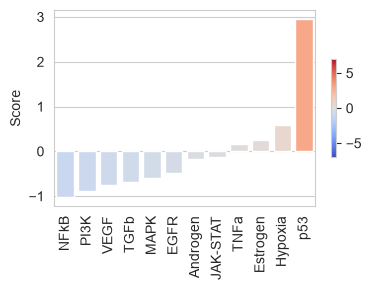

Saved: C:\Users\olaia\Desktop\WGCNA_results\LIANA\tensor_c2c_outputs\progeny_ulm_scores_all_factors.csv


In [54]:
TENSOR_OUTPUT_DIR=Path("C:/Users/olaia/Desktop/WGCNA_results/LIANA/tensor_c2c_outputs")
# 1. PROGENy en humano (evita el paso de traducción roto de decoupler)
net = dc.op.progeny(organism='human', top=5000)

# 2. Orthologs humano->ratón vía el descargador de HCOP de LIANA (ya usa el bucket de
#    Google Cloud de HGNC en vez del FTP de EBI, que está caído)
map_df = li.rs.get_hcop_orthologs(
    target_organism='mouse',
    columns=['human_symbol', 'mouse_symbol'],
    min_evidence=3
).rename(columns={'human_symbol': 'source', 'mouse_symbol': 'target'})

# 3. Traduce la columna 'target' (genesymbol) de PROGENy a símbolos de ratón
net = li.rs.translate_resource(
    net,
    map_df=map_df,
    columns=['target'],
    replace=True,
    one_to_many=1
)

# 4. Sigue igual que antes
lr_pairs_mouse_resource = li.resource.select_resource('mouseconsensus')
lr_progeny = li.rs.generate_lr_geneset(lr_pairs_mouse_resource, net, lr_sep='^').rename(columns={'interaction': 'target'})
estimate, pvals = dc.mt.ulm(lr_loadings.transpose(), lr_progeny, raw=False)
fig_bar = dc.pl.barplot(estimate, age_factor, vertical=True, cmap='coolwarm', vmin=-7, vmax=7, return_fig=True)
if fig_bar is not None:
    fig_bar.savefig(TENSOR_OUTPUT_DIR / f"06_progeny_barplot_{age_factor.replace(' ', '_')}.pdf",
                     format='pdf', bbox_inches='tight')
plt.show()
estimate.to_csv(TENSOR_OUTPUT_DIR / "progeny_ulm_scores_all_factors.csv")
pvals.to_csv(TENSOR_OUTPUT_DIR / "progeny_ulm_pvals_all_factors.csv")
print(f"Saved: {TENSOR_OUTPUT_DIR / 'progeny_ulm_scores_all_factors.csv'}")

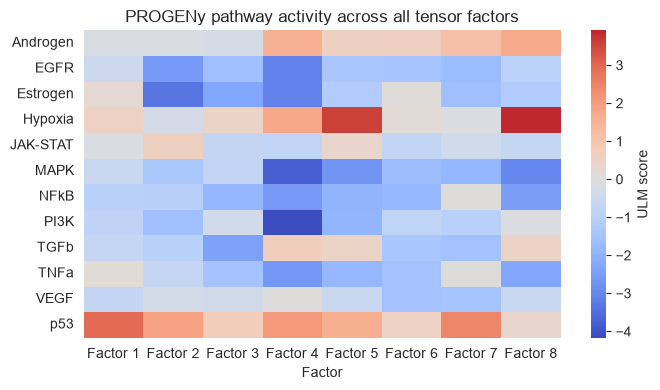

Saved: C:\Users\olaia\Desktop\WGCNA_results\LIANA\tensor_c2c_outputs\07_progeny_heatmap_all_factors.pdf


In [55]:
# Pathway activity across ALL factors at once, for broader context
plt.figure(figsize=(7, max(4, 0.3 * estimate.shape[1])))
sns.heatmap(estimate.T, cmap='coolwarm', center=0, cbar_kws={'label': 'ULM score'})
plt.title('PROGENy pathway activity across all tensor factors')
plt.xlabel('Factor')
plt.tight_layout()
pdf_path = TENSOR_OUTPUT_DIR / "07_progeny_heatmap_all_factors.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {pdf_path}")

## 9.5 GSEA sobre los loadings de LR pairs (familias de señalización CellChatDB)

Complementa el PROGENy de arriba (activación de vías generales) con un enriquecimiento
directamente sobre los **pares ligando-receptor** del tensor, usando las familias de señalización
curadas por CellChatDB (`TGFb`, `NOTCH`, `COLLAGEN`, `WNT`...) en vez de KEGG -- evita los términos
de enfermedad humana (`Breast cancer`, `HPV infection`...) que salen con `KEGG_2019_Mouse`, y no
depende de conversión de mayúsculas entre especies.

In [35]:
import gseapy
import matplotlib as mpl
from statsmodels.stats.multitest import fdrcorrection
TENSOR_OUTPUT_DIR=Path("C:/Users/olaia/Desktop/WGCNA_results/LIANA/tensor_c2c_outputs")
GSEA_OUTPUT_DIR = TENSOR_OUTPUT_DIR / "GSEA"
GSEA_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)



In [37]:
lr_pairs_mouse_cellchat = pd.read_csv(
    'https://raw.githubusercontent.com/LewisLabUCSD/Ligand-Receptor-Pairs/master/Mouse/Mouse-2020-Jin-LR-pairs.csv'
)
lr_pairs_mouse_cellchat = lr_pairs_mouse_cellchat.astype(str)
lr_pairs_mouse_cellchat[['interaction_symbol', 'pathway_name', 'annotation']].head(5)

,interaction_symbol,pathway_name,annotation
0,Tgfb1^Tgfbr1&Tgfbr2,TGFb,Secreted Signaling
1,Tgfb2^Tgfbr1&Tgfbr2,TGFb,Secreted Signaling
2,Tgfb3^Tgfbr1&Tgfbr2,TGFb,Secreted Signaling
3,Tgfb1^Acvr1b&Tgfbr2,TGFb,Secreted Signaling
4,Tgfb1^Acvr1c&Tgfbr2,TGFb,Secreted Signaling


In [39]:
K = 5  # minimo de LR pairs por pathway para conservarlo

pathway_sets = lr_pairs_mouse_cellchat.groupby('pathway_name')['interaction_symbol'].apply(set).to_dict()
lr_set = {k: v for k, v in pathway_sets.items() if len(v) >= K}

# Acotar a los LR pairs realmente detectados en TU tensor de 4 tipos celulares
detected_lr_pairs = set(lr_loadings.index)
lr_set = {pathway: pairs.intersection(detected_lr_pairs) for pathway, pairs in lr_set.items()}
lr_set = {k: v for k, v in lr_set.items() if len(v) >= K}

print(f"Familias de señalización (CellChatDB) con >= {K} LR pairs detectados: {len(lr_set)}")
print(sorted(lr_set.keys()))

c2c.io.export_variable_with_pickle(lr_set, str(GSEA_OUTPUT_DIR / "LR-CellChatDB-pathway-set-mouse.pkl"))

Familias de señalización (CellChatDB) con >= 5 LR pairs detectados: 11
['ANGPTL', 'COLLAGEN', 'EPHA', 'EPHB', 'FGF', 'LAMININ', 'MK', 'NOTCH', 'SEMA4', 'THBS', 'ncWNT']
C:\Users\olaia\Desktop\WGCNA_results\LIANA\tensor_c2c_outputs\GSEA\LR-CellChatDB-pathway-set-mouse.pkl  was correctly saved.


In [41]:
weight = 1
min_size = 5   # mas bajo que en el analisis sin restringir: con solo 4 tipos celulares hay menos LR pairs totales
permutations = 999
significance_threshold = 0.05

for factor in lr_loadings.columns:
    test = lr_loadings[[factor]].reset_index()
    test.columns = [0, 1]
    test = test.sort_values(by=1, ascending=False).reset_index(drop=True)

    gseapy.prerank(
        rnk=test,
        gene_sets=lr_set,
        min_size=min_size,
        weighted_score_type=weight,
        processes=6,
        permutation_num=permutations,
        outdir=str(GSEA_OUTPUT_DIR / factor.replace(' ', '_')),
        format='png',
        seed=6,
    )

print("GSEA done for all factors.")

GSEA done for all factors.


In [42]:
def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Ninguna de estas columnas está presente: {candidates}. Columnas reales: {df.columns.tolist()}")

pvals, terms, factors_list, nes = [], [], [], []

for factor in lr_loadings.columns:
    factor_tag = factor.replace(' ', '_')
    factor_dir = GSEA_OUTPUT_DIR / factor_tag

    report_candidates = list(factor_dir.glob('*report.csv'))
    if not report_candidates:
        print(f"[WARN] No se encontró report para {factor} en {factor_dir}")
        continue
    report_path = report_candidates[0]

    p_report = pd.read_csv(report_path)

    term_col = _pick_col(p_report, ['Term', 'term'])
    nes_col  = _pick_col(p_report, ['NES', 'nes'])
    pval_col = _pick_col(p_report, ['NOM p-val', 'pval', 'p-val', 'Nom p-val'])

    pvals.extend(p_report[pval_col].values.tolist())
    terms.extend(p_report[term_col].values.tolist())
    factors_list.extend([factor] * len(p_report))
    nes.extend(p_report[nes_col].values.tolist())

pval_df = pd.DataFrame({'Factor': factors_list, 'Term': terms, 'NES': nes, 'P-value': pvals})
pval_df = pval_df.dropna(subset=['P-value'])
pval_df['P-value'] = pd.to_numeric(pval_df['P-value']).replace(0., 1. / (permutations + 1))
pval_df['NES'] = pd.to_numeric(pval_df['NES'])
pval_df['Adj. P-value'] = fdrcorrection(pval_df['P-value'].values, alpha=significance_threshold)[1]

pval_df.to_excel(GSEA_OUTPUT_DIR / "GSEA-Adj-Pvals.xlsx", index=False)
pval_df.to_csv(GSEA_OUTPUT_DIR / "GSEA-Adj-Pvals.csv", index=False)
print(f"Total (factor, pathway) testeados: {pval_df.shape[0]}")
pval_df.head()

Total (factor, pathway) testeados: 88


,Factor,Term,NES,P-value,Adj. P-value
0,Factor 1,EPHB,-1.233784,0.045455,0.520521
1,Factor 1,LAMININ,1.129901,0.112112,0.758913
2,Factor 1,COLLAGEN,1.025257,0.360360,1.000000
3,Factor 1,ncWNT,-1.000000,1.000000,1.000000
4,Factor 1,MK,0.976720,0.563207,1.000000


In [45]:
print("Enriched LR pathways (NES > 0, Adj. P < 0.05):")
enriched = pval_df.loc[(pval_df['Adj. P-value'] < significance_threshold) & (pval_df['NES'] > 0)]
display(enriched)
enriched.to_csv(GSEA_OUTPUT_DIR / "enriched_pathways_significant.csv", index=False)

print("\nDepleted LR pathways (NES < 0, Adj. P < 0.05):")
depleted = pval_df.loc[(pval_df['Adj. P-value'] < significance_threshold) & (pval_df['NES'] < 0)]
display(depleted)
depleted.to_csv(GSEA_OUTPUT_DIR / "depleted_pathways_significant.csv", index=False)

# Vista exploratoria sin filtro de significancia, por si el corte estricto deja poco -- util para hipotesis
top_per_factor = pval_df.sort_values(['Factor', 'NES'], ascending=[True, False]).groupby('Factor').head(5)
top_per_factor.to_csv(GSEA_OUTPUT_DIR / "top5_pathways_per_factor_unfiltered.csv", index=False)
top_per_factor

Enriched LR pathways (NES > 0, Adj. P < 0.05):


,Factor,Term,NES,P-value,Adj. P-value



Depleted LR pathways (NES < 0, Adj. P < 0.05):


,Factor,Term,NES,P-value,Adj. P-value
11,Factor 2,FGF,-1.286174,0.001,0.0176
22,Factor 3,SEMA4,-1.239200,0.001,0.0176
66,Factor 7,FGF,-1.321521,0.001,0.0176
67,Factor 7,ANGPTL,-1.215757,0.001,0.0176
77,Factor 8,EPHA,-1.322802,0.001,0.0176


,Factor,Term,NES,P-value,Adj. P-value
1,Factor 1,LAMININ,1.129901,0.112112,0.758913
2,Factor 1,COLLAGEN,1.025257,0.360360,1.000000
4,Factor 1,MK,0.976720,0.563207,1.000000
5,Factor 1,SEMA4,0.928955,0.683622,1.000000
6,Factor 1,ANGPTL,0.905790,0.747208,1.000000
12,Factor 2,EPHB,1.209475,0.100815,0.739308
13,Factor 2,THBS,1.201068,0.065065,0.520521
14,Factor 2,EPHA,1.085363,0.290616,1.000000
15,Factor 2,LAMININ,1.002855,0.469469,1.000000
16,Factor 2,NOTCH,0.997767,0.493493,1.000000


In [47]:
# Shim: matplotlib >= 3.9 elimino mpl.cm.get_cmap, pero cell2cell todavia lo usa internamente
if not hasattr(mpl.cm, 'get_cmap'):
    mpl.cm.get_cmap = plt.get_cmap

pval_pivot = pval_df.pivot(index="Term", columns="Factor", values="Adj. P-value").fillna(1.)
scores = pval_df.pivot(index="Term", columns="Factor", values="NES").fillna(0)

with sns.axes_style("darkgrid"):
    dotplot = c2c.plotting.pval_plot.generate_dot_plot(
        pval_df=pval_pivot,
        score_df=scores,
        significance=significance_threshold,
        xlabel='',
        ylabel='Señalización (CellChatDB, mouse)',
        cbar_title='NES',
        cmap='PuOr',
        figsize=(9, max(4, 0.4 * pval_pivot.shape[0])),
        label_size=14,
        title_size=14,
        tick_size=11,
        filename=str(GSEA_OUTPUT_DIR / "GSEA-Dotplot.svg"),
    )
plt.savefig(GSEA_OUTPUT_DIR / "GSEA-Dotplot.pdf", format='pdf', bbox_inches='tight')
print(f"Saved: {GSEA_OUTPUT_DIR / 'GSEA-Dotplot.pdf'}")

Saved: C:\Users\olaia\Desktop\WGCNA_results\LIANA\tensor_c2c_outputs\GSEA\GSEA-Dotplot.pdf
